# m01 Multi-Vehicle Dataloader Smoke Test

This notebook is the multi-vehicle analogue of `01_dataloader_smoke_test.ipynb`. It checks the raw two-vehicle data, verifies leakage-free audio features, and writes a processed two-tower dataset with per-vehicle labels preserved.

The important smoke-test invariant is: after processing, each `(time_id, subset)` row keeps `utility_vehicle*`, `closest_node_vehicle*`, and `contains_closest_vehicle*` columns. The default backward-compatible `utility` column is the summed utility, while `contains_closest_node` is set to the all-vehicles containment target.


Project root: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt
Data dir:     d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900
Sensor CSV:   d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\Graces_Quarters\nodes_gps.csv
All GPS CSVs: ['CAR1-20250815-090042.csv', 'TRUCK1-20250815-090042.csv', 'WARTHOG3-20250815-090042.csv']
Processing:   ['CAR1-20250815-090042.csv', 'WARTHOG3-20250815-090042.csv']
Excluded:     ['TRUCK1-20250815-090042.csv']
Nodes:        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
FLAC files:   10
Resampling:   audio and GPS -> 200ms


,file,rows,duration_min,displacement_m,path_length_m,median_dt_ms,moving
0,CAR1-20250815-090042.csv,7358,24.906667,65.813355,5592.626602,200.0,True
1,TRUCK1-20250815-090042.csv,7221,24.903333,0.006963,5.863103,200.0,False
2,WARTHOG3-20250815-090042.csv,7086,24.920000,57.229906,5890.559182,200.0,True


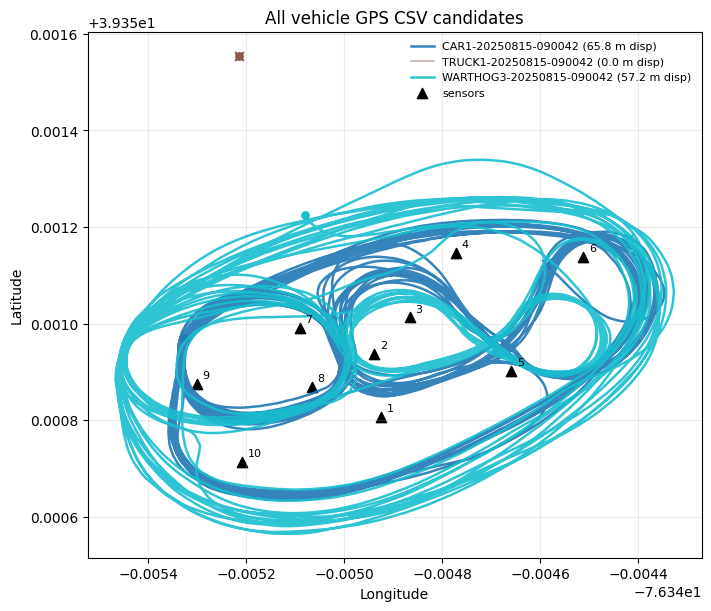

Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_1_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_2_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_3_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_4_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_5_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_6_respeaker.flac
Loaded FLAC: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\raw\20250815_0900\20250815_090042_dvpg_gq_orin_7_

,raw_rows,valid_rows,valid_fraction,duration_min,median_dt_ms,all_dt_expected,vehicles_processed,gps_candidates_plotted,nodes
0,6970,6625,0.950502,24.653333,200.0,False,2,3,10


Per-vehicle motion and closest-node summary


,vehicle,valid_rows,closest_nodes_seen,top_closest_node,top_closest_frac,median_step_m,p95_step_m
0,vehicle1,6625,10,5,0.199245,0.708034,1.170126
1,vehicle2,6625,10,5,0.200302,0.785295,1.205803


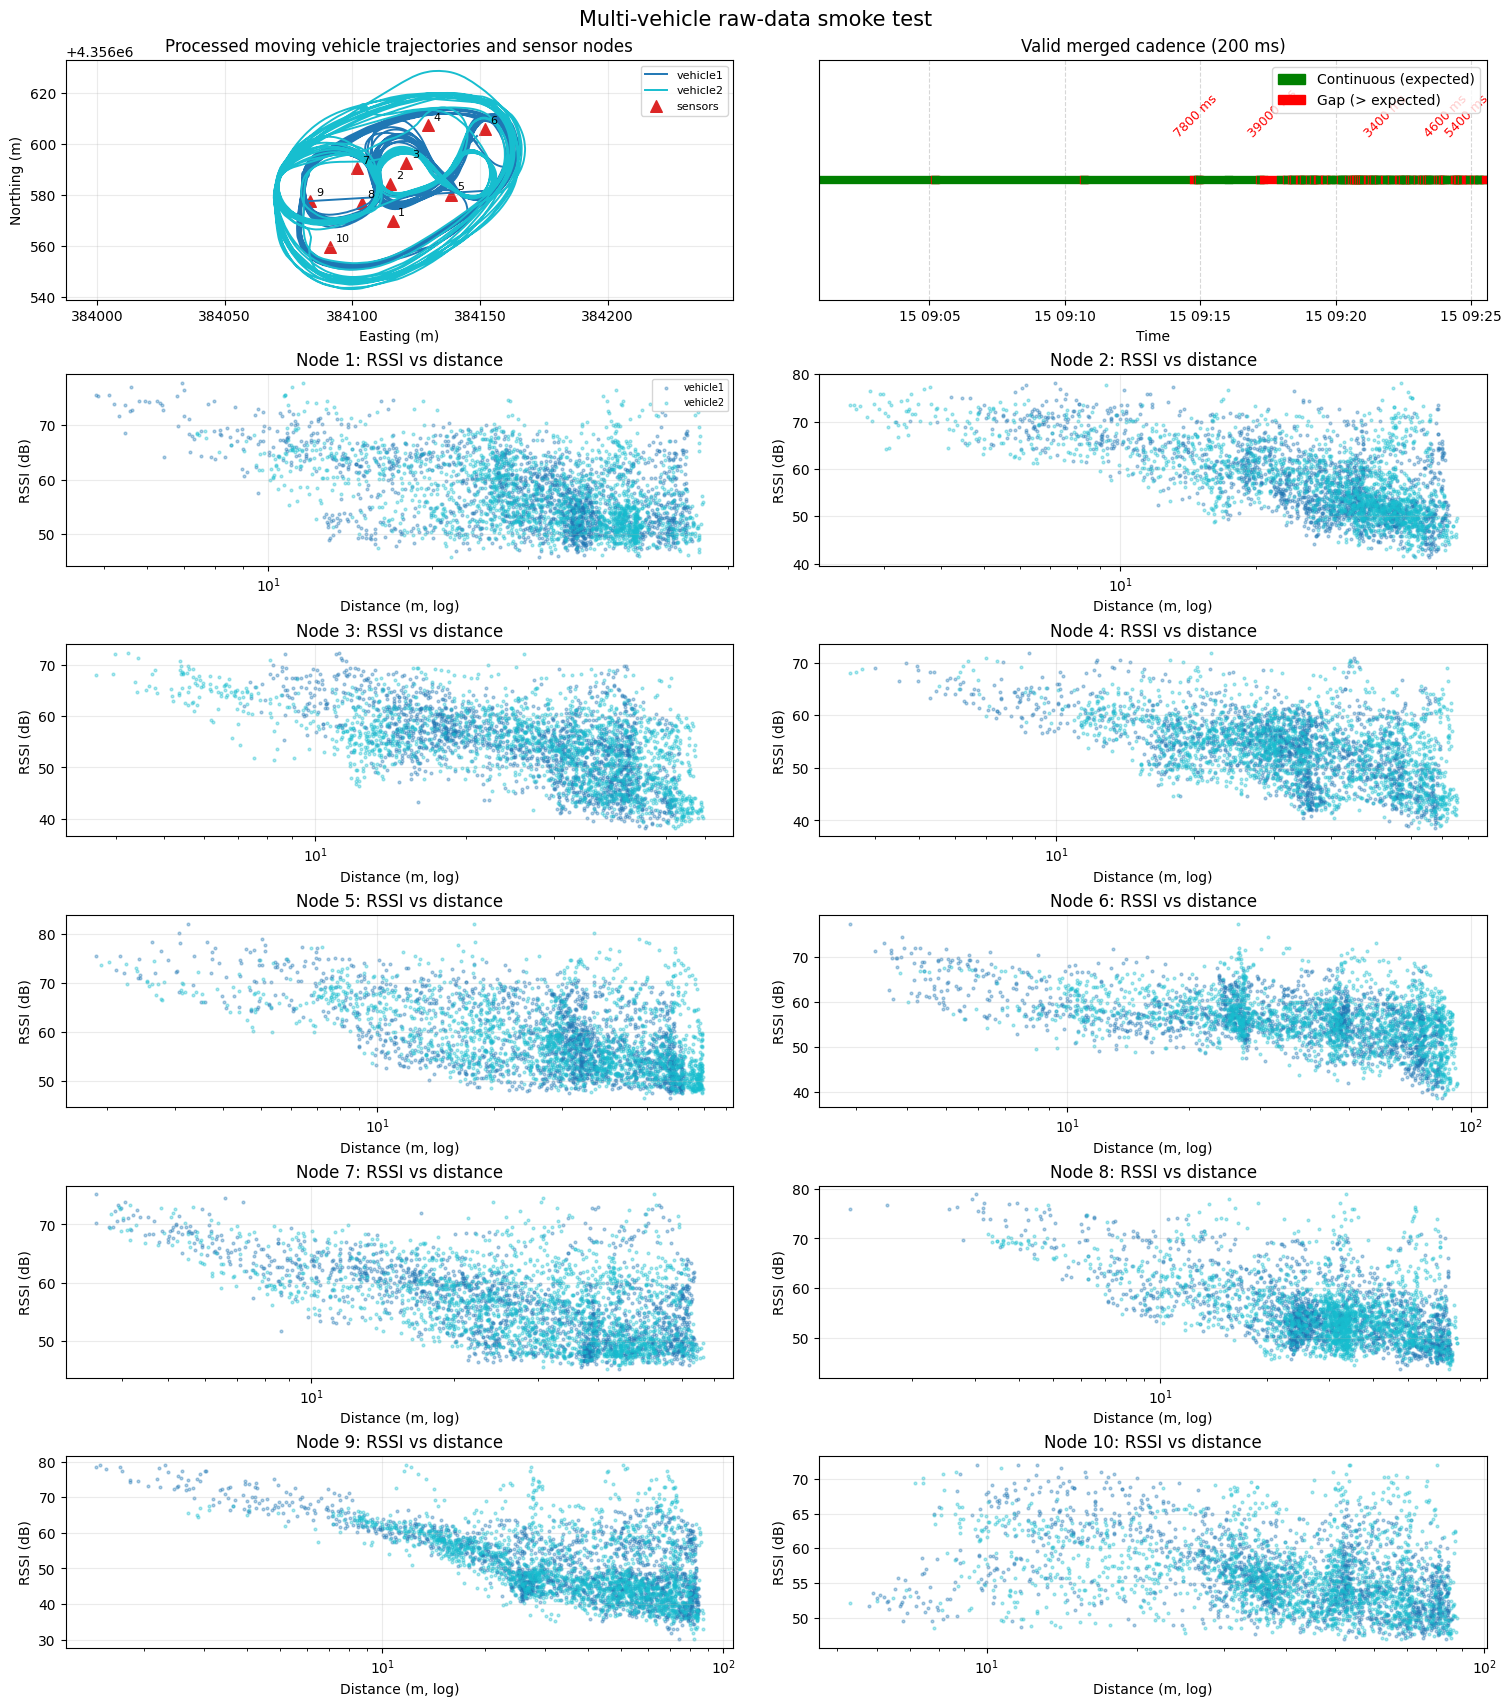

In [3]:
from pathlib import Path
import importlib
import math
import re
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import multi_dataloader
importlib.reload(multi_dataloader)
from multi_dataloader import load_data, plot_gap_timeline

SAMPLE_MS = 200
RESAMPLE_RATE = f"{SAMPLE_MS}ms"
CHUNK_MS = 10
MOVING_DISPLACEMENT_THRESHOLD_M = 15.0

# Set DATA_DIR / SENSOR_CSV / GPS_CSVS manually above this cell if needed.
# If GPS_CSVS is unset, the cell plots every vehicle-looking CSV and processes only moving tracks.
DATA_DIR_CANDIDATES = [
    PROJECT_ROOT / "data" / "raw" / "20250815_0900",
    PROJECT_ROOT / "data" / "20250815_0900",
    PROJECT_ROOT / "data" / "raw" / "MultiVehicle",
]


def _find_data_dir(candidates):
    for path in candidates:
        if not path.exists():
            continue
        flacs = list(path.glob("*_respeaker.flac"))
        csvs = list(path.glob("*.csv"))
        gps_csvs = [p for p in csvs if "node" not in p.name.lower()]
        if flacs and len(gps_csvs) >= 2:
            return path
    return None


def _find_sensor_csv(data_dir: Path) -> Path:
    candidates = [
        data_dir / "gq_node_gps.csv",
        data_dir / "nodes_gps.csv",
        data_dir / "wp_node_gps.csv",
        PROJECT_ROOT / "data" / "raw" / "Graces_Quarters" / "nodes_gps.csv",
        PROJECT_ROOT / "data" / "raw" / "wp_node_gps.csv",
    ]
    for path in candidates:
        if path.exists():
            return path
    node_like = [p for p in data_dir.glob("*.csv") if "node" in p.name.lower()]
    if node_like:
        return sorted(node_like)[0]
    raise FileNotFoundError(f"Could not find a node GPS CSV for {data_dir}")


def _find_vehicle_gps_csvs(data_dir: Path, sensor_csv: Path) -> list[Path]:
    out = []
    for path in sorted(data_dir.glob("*.csv")):
        if path.resolve() == sensor_csv.resolve():
            continue
        name = path.name.lower()
        if "node" in name or "sensor" in name:
            continue
        out.append(path)
    if len(out) < 2:
        raise FileNotFoundError(
            f"Need at least two vehicle GPS CSVs in {data_dir}; found {len(out)}: {out}"
        )
    return out


def _read_raw_gps(path: Path) -> pd.DataFrame:
    raw = pd.read_csv(path, header=None)
    if raw.shape[1] < 3:
        raise ValueError(f"{path.name} must have at least timestamp, latitude, longitude columns")
    out = pd.DataFrame(
        {
            "datetime": pd.to_datetime(raw.iloc[:, 0], errors="coerce"),
            "lat": pd.to_numeric(raw.iloc[:, 1], errors="coerce"),
            "lon": pd.to_numeric(raw.iloc[:, 2], errors="coerce"),
        }
    ).dropna(subset=["datetime", "lat", "lon"])
    out = out.drop_duplicates(subset="datetime", keep="first").sort_values("datetime")
    out["source"] = path.stem
    return out


def _local_distance_m(lat1, lon1, lat2, lon2):
    radius_m = 6_371_000.0
    lat1, lon1, lat2, lon2 = map(math.radians, [lat1, lon1, lat2, lon2])
    x = (lon2 - lon1) * math.cos((lat1 + lat2) / 2.0)
    y = lat2 - lat1
    return radius_m * math.sqrt(x * x + y * y)


def _gps_quality(path: Path) -> dict:
    gps = _read_raw_gps(path)
    if len(gps) < 2:
        return {
            "file": path.name,
            "rows": len(gps),
            "duration_min": np.nan,
            "displacement_m": 0.0,
            "path_length_m": 0.0,
            "median_dt_ms": np.nan,
            "moving": False,
            "path": path,
        }
    lat = gps["lat"].to_numpy(dtype=float)
    lon = gps["lon"].to_numpy(dtype=float)
    steps = np.array(
        [_local_distance_m(lat[i - 1], lon[i - 1], lat[i], lon[i]) for i in range(1, len(gps))],
        dtype=float,
    )
    displacement = _local_distance_m(lat[0], lon[0], lat[-1], lon[-1])
    dt_ms = gps["datetime"].diff().dropna().dt.total_seconds().to_numpy() * 1000.0
    return {
        "file": path.name,
        "rows": int(len(gps)),
        "duration_min": float((gps["datetime"].iloc[-1] - gps["datetime"].iloc[0]).total_seconds() / 60.0),
        "displacement_m": float(displacement),
        "path_length_m": float(np.nansum(steps)),
        "median_dt_ms": float(np.nanmedian(dt_ms)) if len(dt_ms) else np.nan,
        "moving": bool(displacement >= MOVING_DISPLACEMENT_THRESHOLD_M),
        "path": path,
    }


def _plot_all_raw_gps(gps_paths: list[Path], sensor_csv: Path | None = None):
    fig, ax = plt.subplots(figsize=(7.0, 6.0), constrained_layout=True)
    colors = plt.cm.tab10(np.linspace(0, 1, max(len(gps_paths), 1)))
    for color, path in zip(colors, gps_paths):
        gps = _read_raw_gps(path)
        quality = _gps_quality(path)
        lw = 1.8 if quality["moving"] else 1.2
        alpha = 0.9 if quality["moving"] else 0.45
        label = f"{path.stem} ({quality['displacement_m']:.1f} m disp)"
        ax.plot(gps["lon"], gps["lat"], color=color, lw=lw, alpha=alpha, label=label)
        if len(gps):
            ax.scatter(gps["lon"].iloc[0], gps["lat"].iloc[0], color=color, s=28, marker="o")
            ax.scatter(gps["lon"].iloc[-1], gps["lat"].iloc[-1], color=color, s=40, marker="x")
    if sensor_csv is not None and sensor_csv.exists():
        sensors = pd.read_csv(sensor_csv)
        lat_col = "Lat" if "Lat" in sensors.columns else "Latitude"
        lon_col = "Lon" if "Lon" in sensors.columns else "Longitude"
        node_col = "Node #" if "Node #" in sensors.columns else "Node"
        ax.scatter(sensors[lon_col], sensors[lat_col], color="black", marker="^", s=55, label="sensors")
        for _, row in sensors.iterrows():
            ax.annotate(str(int(row[node_col])), (row[lon_col], row[lat_col]), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax.set_title("All vehicle GPS CSV candidates")
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.25)
    ax.legend(loc="best", fontsize=8, frameon=False)
    return fig


if "DATA_DIR" not in globals():
    DATA_DIR = _find_data_dir(DATA_DIR_CANDIDATES)
if DATA_DIR is None or not Path(DATA_DIR).exists():
    raise FileNotFoundError(
        "Set DATA_DIR to the multi-vehicle raw-data folder before running this cell. "
        f"Tried: {[str(p) for p in DATA_DIR_CANDIDATES]}"
    )
DATA_DIR = Path(DATA_DIR)

SENSOR_CSV = Path(globals().get("SENSOR_CSV", _find_sensor_csv(DATA_DIR)))
ALL_GPS_CSVS = _find_vehicle_gps_csvs(DATA_DIR, SENSOR_CSV)
gps_quality_df = pd.DataFrame([_gps_quality(path) for path in ALL_GPS_CSVS]).sort_values("file").reset_index(drop=True)

if "GPS_CSVS" in globals():
    GPS_CSVS = [Path(p) for p in GPS_CSVS]
else:
    GPS_CSVS = gps_quality_df.loc[gps_quality_df["moving"], "path"].tolist()

if len(GPS_CSVS) < 2:
    raise ValueError(
        "Fewer than two moving GPS CSVs were selected. Set GPS_CSVS manually after inspecting gps_quality_df."
    )

sensor_df = pd.read_csv(SENSOR_CSV)
node_col = "Node #" if "Node #" in sensor_df.columns else "Node"
node_list = sorted(sensor_df[node_col].astype(int).tolist())
flac_files = sorted(DATA_DIR.glob("*_respeaker.flac"))

print(f"Project root: {PROJECT_ROOT}")
print(f"Data dir:     {DATA_DIR}")
print(f"Sensor CSV:   {SENSOR_CSV}")
print(f"All GPS CSVs: {[p.name for p in ALL_GPS_CSVS]}")
print(f"Processing:   {[p.name for p in GPS_CSVS]}")
print(f"Excluded:     {[p.name for p in ALL_GPS_CSVS if p not in GPS_CSVS]}")
print(f"Nodes:        {node_list}")
print(f"FLAC files:   {len(flac_files)}")
print(f"Resampling:   audio and GPS -> {RESAMPLE_RATE}")

display(gps_quality_df.drop(columns=["path"]))
fig = _plot_all_raw_gps(ALL_GPS_CSVS, SENSOR_CSV)
plt.show()

gdf_cleaned, valid_indices, gdf_nodes = load_data(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    gps_csvs=GPS_CSVS,
    node_list=node_list,
    chunk_ms=CHUNK_MS,
    sample_ms=SAMPLE_MS,
    resample_rate=RESAMPLE_RATE,
    plot_gaps=False,
)

seq = gdf_cleaned.iloc[valid_indices].copy().sort_index()
vehicle_labels = sorted(
    [col.replace("geometry_", "") for col in seq.columns if col.startswith("geometry_vehicle")],
    key=lambda v: int(re.sub(r"\D+", "", v) or 0),
)
assert len(vehicle_labels) == len(GPS_CSVS), (vehicle_labels, GPS_CSVS)
assert len(vehicle_labels) >= 2, f"Expected at least two vehicles; detected {vehicle_labels}"

missing_distance_cols = []
for vehicle in vehicle_labels:
    for node in node_list:
        col = f"distance_to_{node}_{vehicle}"
        if col not in seq.columns:
            missing_distance_cols.append(col)
assert not missing_distance_cols, missing_distance_cols[:10]


def _vehicle_closest_nodes(frame: pd.DataFrame, vehicle: str) -> pd.Series:
    cols = [f"distance_to_{node}_{vehicle}" for node in node_list]
    dist = frame[cols].to_numpy(dtype=float)
    closest_idx = np.nanargmin(dist, axis=1)
    return pd.Series([node_list[i] for i in closest_idx], index=frame.index, name=vehicle)


summary_rows = []
expected_dt = pd.Timedelta(milliseconds=SAMPLE_MS)
dt = seq.index.to_series().diff().dropna()
for vehicle in vehicle_labels:
    closest = _vehicle_closest_nodes(seq, vehicle)
    geom = seq[f"geometry_{vehicle}"]
    step_m = []
    prev = None
    for geom_now in geom:
        if prev is None or geom_now is None:
            step_m.append(np.nan)
        else:
            step_m.append(float(geom_now.distance(prev)))
        prev = geom_now
    step_m = pd.Series(step_m, index=seq.index)
    summary_rows.append(
        {
            "vehicle": vehicle,
            "valid_rows": len(seq),
            "closest_nodes_seen": int(closest.nunique()),
            "top_closest_node": int(closest.value_counts().idxmax()),
            "top_closest_frac": float(closest.value_counts(normalize=True).iloc[0]),
            "median_step_m": float(step_m.median()),
            "p95_step_m": float(step_m.quantile(0.95)),
        }
    )

smoke_summary = pd.DataFrame(
    [
        {
            "raw_rows": len(gdf_cleaned),
            "valid_rows": len(seq),
            "valid_fraction": len(seq) / max(len(gdf_cleaned), 1),
            "duration_min": (seq.index.max() - seq.index.min()).total_seconds() / 60.0,
            "median_dt_ms": dt.median().total_seconds() * 1000.0 if len(dt) else np.nan,
            "all_dt_expected": bool((dt == expected_dt).all()) if len(dt) else False,
            "vehicles_processed": len(vehicle_labels),
            "gps_candidates_plotted": len(ALL_GPS_CSVS),
            "nodes": len(node_list),
        }
    ]
)

print("\nMerged-data smoke summary")
display(smoke_summary)
print("Per-vehicle motion and closest-node summary")
display(pd.DataFrame(summary_rows))


def plot_multi_vehicle_overview(seq, gdf_nodes, node_list, vehicle_labels, sample_ms=200, max_points=1800):
    ncols = 2
    n_node_rows = max(1, int(np.ceil(len(node_list) / ncols)))
    fig = plt.figure(figsize=(15, 4.2 + 2.55 * n_node_rows), constrained_layout=True)
    gs = fig.add_gridspec(n_node_rows + 1, ncols, height_ratios=[1.25] + [1.0] * n_node_rows)

    ax_map = fig.add_subplot(gs[0, 0])
    colors = plt.cm.tab10(np.linspace(0, 1, len(vehicle_labels)))
    for color, vehicle in zip(colors, vehicle_labels):
        geoms = seq[f"geometry_{vehicle}"].dropna()
        xs = [g.x for g in geoms]
        ys = [g.y for g in geoms]
        ax_map.plot(xs, ys, lw=1.4, color=color, label=vehicle)
        ax_map.scatter(xs[0], ys[0], s=28, color=color, marker="o")
        ax_map.scatter(xs[-1], ys[-1], s=36, color=color, marker="x")
    gdf_nodes.plot(ax=ax_map, color="#dc2626", marker="^", markersize=70, label="sensors")
    for _, row in gdf_nodes.iterrows():
        node_id = row.get("Node #", row.get("Node", ""))
        ax_map.annotate(str(node_id), (row.geometry.x, row.geometry.y), xytext=(4, 4), textcoords="offset points", fontsize=8)
    ax_map.set_title("Processed moving vehicle trajectories and sensor nodes")
    ax_map.set_xlabel("Easting (m)")
    ax_map.set_ylabel("Northing (m)")
    ax_map.grid(True, alpha=0.25)
    ax_map.legend(loc="best", fontsize=8)
    ax_map.set_aspect("equal", adjustable="datalim")

    ax_gap = fig.add_subplot(gs[0, 1])
    plot_gap_timeline(seq, expected_freq_ms=sample_ms, title=f"Valid merged cadence ({sample_ms} ms)", ax=ax_gap)

    for idx, node in enumerate(node_list):
        ax = fig.add_subplot(gs[1 + idx // ncols, idx % ncols])
        rss_col = f"rpi{node}"
        for color, vehicle in zip(colors, vehicle_labels):
            dist_col = f"distance_to_{node}_{vehicle}"
            sub = seq[[rss_col, dist_col]].replace([np.inf, -np.inf], np.nan).dropna()
            sub = sub[sub[dist_col] > 0]
            if len(sub) > max_points:
                sub = sub.sample(max_points, random_state=22).sort_index()
            ax.scatter(sub[dist_col], sub[rss_col], s=4, alpha=0.35, color=color, label=vehicle)
        ax.set_xscale("log")
        ax.set_title(f"Node {node}: RSSI vs distance")
        ax.set_xlabel("Distance (m, log)")
        ax.set_ylabel("RSSI (dB)")
        ax.grid(True, alpha=0.25)
        if idx == 0:
            ax.legend(loc="best", fontsize=7)

    for idx in range(len(node_list), n_node_rows * ncols):
        ax = fig.add_subplot(gs[1 + idx // ncols, idx % ncols])
        ax.axis("off")

    fig.suptitle("Multi-vehicle raw-data smoke test", fontsize=15)
    return fig


fig = plot_multi_vehicle_overview(seq, gdf_nodes, node_list, vehicle_labels, sample_ms=SAMPLE_MS)
plt.show()


Loaded audio features: node 1, 20250815_090042_dvpg_gq_orin_1_respeaker.flac, 7478 rows at 200 ms
Loaded audio features: node 2, 20250815_090042_dvpg_gq_orin_2_respeaker.flac, 7478 rows at 200 ms
Loaded audio features: node 3, 20250815_090042_dvpg_gq_orin_3_respeaker.flac, 7477 rows at 200 ms
Loaded audio features: node 4, 20250815_090042_dvpg_gq_orin_4_respeaker.flac, 7477 rows at 200 ms
Loaded audio features: node 5, 20250815_090042_dvpg_gq_orin_5_respeaker.flac, 7477 rows at 200 ms
Loaded audio features: node 6, 20250815_090042_dvpg_gq_orin_6_respeaker.flac, 7477 rows at 200 ms
Loaded audio features: node 7, 20250815_090042_dvpg_gq_orin_7_respeaker.flac, 7478 rows at 200 ms
Loaded audio features: node 8, 20250815_090042_dvpg_gq_orin_8_respeaker.flac, 7478 rows at 200 ms
Loaded audio features: node 9, 20250815_090042_dvpg_gq_orin_9_respeaker.flac, 7478 rows at 200 ms
Loaded audio features: node 10, 20250815_090042_dvpg_gq_orin_10_respeaker.flac, 7477 rows at 200 ms
Audio feature smok

,node,rows,missing_frac,rms_db_median,centroid_hz_median
0,1,7478,0.0,-35.311249,137.445099
1,2,7478,0.0,-35.939980,114.031311
2,3,7477,0.0,-36.327671,119.975060
3,4,7477,0.0,-36.649487,118.136261
4,5,7477,0.0,-34.086098,154.833435
5,6,7477,0.0,-34.642521,110.273712
6,7,7478,0.0,-35.461662,187.458206
7,8,7478,0.0,-37.029266,188.859528
8,9,7478,0.0,-42.191063,156.399811
9,10,7477,0.0,-35.482227,153.480286


,n1_rms_db,n1_peak_db,n1_crest_factor_db,n1_zcr,n1_spectral_centroid_hz,n1_spectral_bandwidth_hz,n1_spectral_rolloff85_hz,n1_spectral_flatness,n1_spectral_entropy,n1_band_20_120_db,...,range_band_500_2000_ratio,argmax_node_band_500_2000_ratio,mean_low_to_voice_db,std_low_to_voice_db,range_low_to_voice_db,argmax_node_low_to_voice_db,mean_mid_to_voice_db,std_mid_to_voice_db,range_mid_to_voice_db,argmax_node_mid_to_voice_db
datetime,,,,,,,,,,,,,,,,,,,,,
2025-08-15 09:00:42.000,-41.812195,-33.225307,8.586887,0.039700,173.367203,280.559296,400.0,0.002817,0.420856,19.778465,...,0.095127,5.0,14.593672,7.936437,20.009802,2.0,9.174790,4.310747,13.141850,4.0
2025-08-15 09:00:42.200,-42.250790,-31.155048,11.095743,0.042201,177.686676,297.223083,415.0,0.003163,0.476066,18.867720,...,0.203117,8.0,14.561752,8.428176,23.071516,2.0,9.338499,3.922424,12.006069,4.0
2025-08-15 09:00:42.400,-42.359585,-32.200367,10.159218,0.032198,220.373917,318.012543,420.0,0.004001,0.534892,17.092224,...,0.125973,8.0,14.552736,8.685284,22.364809,2.0,9.434320,4.433499,13.459366,4.0


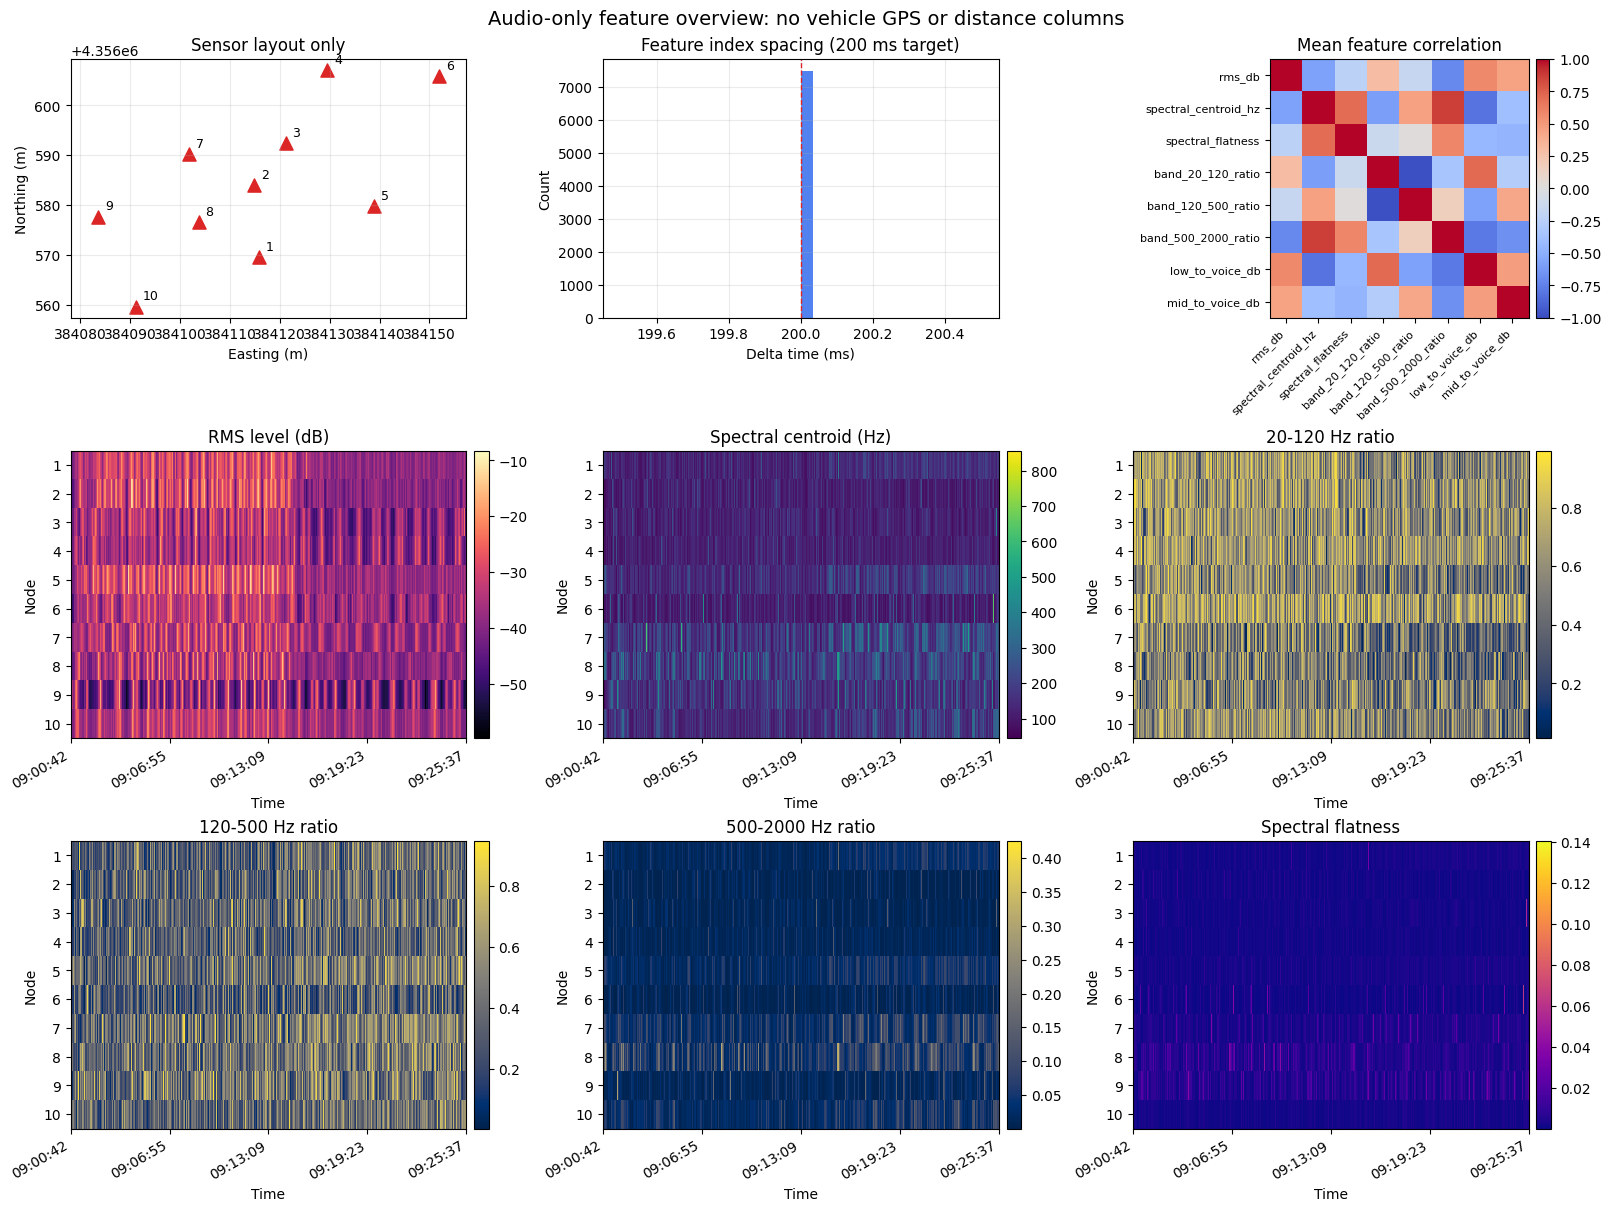

In [2]:
from pathlib import Path
import importlib
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import audio_feature_dataloader
importlib.reload(audio_feature_dataloader)
from audio_feature_dataloader import build_audio_feature_dataset, plot_audio_feature_overview

assert "DATA_DIR" in globals(), "Run the raw-data smoke-test cell first."
assert "SENSOR_CSV" in globals(), "Run the raw-data smoke-test cell first."
assert "node_list" in globals(), "Run the raw-data smoke-test cell first."

AUDIO_SAMPLE_MS = SAMPLE_MS if "SAMPLE_MS" in globals() else 200

audio_feature_df, audio_feature_long, audio_gdf_nodes = build_audio_feature_dataset(
    data_dir=DATA_DIR,
    sensor_csv=SENSOR_CSV,
    node_list=node_list,
    sample_ms=AUDIO_SAMPLE_MS,
    add_cross_sensor=True,
)

forbidden_tokens = ("latitude", "longitude", "distance_to", "vehicle_x", "vehicle_y", "geometry_vehicle")
leak_cols = [col for col in audio_feature_df.columns if any(tok in col.lower() for tok in forbidden_tokens)]
assert not leak_cols, f"Potential target/GPS leakage columns in audio features: {leak_cols[:20]}"

coverage_rows = []
for node in node_list:
    node_rows = audio_feature_long[audio_feature_long["node"].astype(int).eq(int(node))]
    coverage_rows.append(
        {
            "node": int(node),
            "rows": len(node_rows),
            "missing_frac": float(node_rows.isna().mean(numeric_only=True).mean()),
            "rms_db_median": float(node_rows["rms_db"].median()) if "rms_db" in node_rows else np.nan,
            "centroid_hz_median": float(node_rows["spectral_centroid_hz"].median()) if "spectral_centroid_hz" in node_rows else np.nan,
        }
    )

print("Audio feature smoke summary")
print(f"audio_feature_df shape:   {audio_feature_df.shape}")
print(f"audio_feature_long shape: {audio_feature_long.shape}")
print("No vehicle coordinate, distance-to-vehicle, or target columns are present in audio_feature_df.")
display(pd.DataFrame(coverage_rows))
display(audio_feature_df.head(3))

fig = plot_audio_feature_overview(
    feature_df=audio_feature_df,
    node_feature_df=audio_feature_long,
    gdf_nodes=audio_gdf_nodes,
    node_list=node_list,
    sample_ms=AUDIO_SAMPLE_MS,
)
plt.show()


In [11]:
# Save canonical interim observables only.
# Later modeling notebooks should build context/action features and utilities from these CSVs.

import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

REQUIRED = [
    "PROJECT_ROOT",
    "DATA_DIR",
    "SENSOR_CSV",
    "GPS_CSVS",
    "SAMPLE_MS",
    "gdf_cleaned",
    "gdf_nodes",
    "valid_indices",
    "node_list",
    "audio_feature_df",
    "audio_feature_long",
]
missing = [name for name in REQUIRED if name not in globals()]
if missing:
    raise RuntimeError(f"Run the raw-data and audio-feature cells first. Missing: {missing}")

INTERIM_DIR = PROJECT_ROOT / "data" / "interim" / "20250815_0900_multi_vehicle"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)
started = time.time()

ordered_nodes = sorted(int(n) for n in node_list)
vehicle_labels = sorted(
    [col.replace("geometry_", "") for col in gdf_cleaned.columns if col.startswith("geometry_vehicle")],
    key=lambda x: int(x.replace("vehicle", "")),
)
if not vehicle_labels:
    raise RuntimeError("No geometry_vehicle* columns found in gdf_cleaned.")

all_times = pd.DatetimeIndex(gdf_cleaned.index).sort_values()
valid_times = pd.DatetimeIndex(gdf_cleaned.iloc[valid_indices].index).sort_values()
valid_time_to_id = {dt: i for i, dt in enumerate(valid_times)}

def _time_frame(times: pd.DatetimeIndex) -> pd.DataFrame:
    out = pd.DataFrame({"datetime": pd.DatetimeIndex(times)})
    out["is_valid_model_timestep"] = out["datetime"].isin(valid_times).astype(int)
    out["time_id"] = out["datetime"].map(valid_time_to_id)
    return out

time_index_df = _time_frame(all_times)
time_index_df["row_id"] = np.arange(len(time_index_df), dtype=np.int32)
time_index_df = time_index_df[["row_id", "datetime", "is_valid_model_timestep", "time_id"]]

# RSSI dB by timestamp. The multi-dataloader has already converted rpi* powers to dB.
rssi_cols = [f"rpi{node}" for node in ordered_nodes if f"rpi{node}" in gdf_cleaned.columns]
rssi_db_df = time_index_df.merge(
    gdf_cleaned[rssi_cols].reset_index().rename(columns={"index": "datetime"}),
    on="datetime",
    how="left",
)

# Vehicle positions in long format. Coordinates are projected local meters plus source lat/lon.
vehicle_position_rows = []
for vehicle in vehicle_labels:
    lat_col = f"{vehicle}_lat"
    lon_col = f"{vehicle}_lon"
    geom_col = f"geometry_{vehicle}"
    frame = pd.DataFrame({"datetime": all_times})
    frame["vehicle"] = vehicle
    frame["latitude"] = gdf_cleaned.loc[all_times, lat_col].to_numpy(dtype=float) if lat_col in gdf_cleaned.columns else np.nan
    frame["longitude"] = gdf_cleaned.loc[all_times, lon_col].to_numpy(dtype=float) if lon_col in gdf_cleaned.columns else np.nan
    geoms = gdf_cleaned.loc[all_times, geom_col]
    frame["vehicle_x_m"] = [float(g.x) if g is not None else np.nan for g in geoms]
    frame["vehicle_y_m"] = [float(g.y) if g is not None else np.nan for g in geoms]
    vehicle_position_rows.append(frame)
vehicle_positions_df = pd.concat(vehicle_position_rows, ignore_index=True)
vehicle_positions_df = vehicle_positions_df.merge(time_index_df[["datetime", "is_valid_model_timestep", "time_id"]], on="datetime", how="left")

# Distances and distance ranks from every vehicle to every node.
distance_rows = []
for vehicle_idx, vehicle in enumerate(vehicle_labels, start=1):
    dist_cols = [f"distance_to_{node}_vehicle{vehicle_idx}" for node in ordered_nodes]
    missing_dist = [col for col in dist_cols if col not in gdf_cleaned.columns]
    if missing_dist:
        raise RuntimeError(f"Missing distance columns for {vehicle}: {missing_dist[:5]}")
    dist_mat = gdf_cleaned.loc[all_times, dist_cols].to_numpy(dtype=float)
    rank_mat = np.empty_like(dist_mat, dtype=np.int16)
    order = np.argsort(dist_mat, axis=1)
    row_idx = np.arange(len(all_times))[:, None]
    rank_mat[row_idx, order] = np.arange(1, len(ordered_nodes) + 1, dtype=np.int16)[None, :]
    closest_idx = np.argmin(dist_mat, axis=1)
    vehicle_dist = pd.DataFrame({
        "datetime": np.repeat(all_times.to_numpy(dtype="datetime64[ns]"), len(ordered_nodes)),
        "vehicle": vehicle,
        "node": np.tile(np.asarray(ordered_nodes, dtype=np.int16), len(all_times)),
        "distance_to_vehicle_m": dist_mat.reshape(-1),
        "distance_rank": rank_mat.reshape(-1),
        "is_closest_node": (rank_mat.reshape(-1) == 1).astype(np.int8),
        "closest_node": np.repeat(np.asarray(ordered_nodes, dtype=np.int16)[closest_idx], len(ordered_nodes)),
    })
    distance_rows.append(vehicle_dist)
vehicle_node_distances_df = pd.concat(distance_rows, ignore_index=True)
vehicle_node_distances_df = vehicle_node_distances_df.merge(
    time_index_df[["datetime", "is_valid_model_timestep", "time_id"]],
    on="datetime",
    how="left",
)

# Sensor geometry in source lat/lon and projected local coordinates.
nodes = gdf_nodes.copy()
node_id_col = "Node #" if "Node #" in nodes.columns else "Node"
nodes[node_id_col] = nodes[node_id_col].astype(int)
nodes = nodes[nodes[node_id_col].isin(ordered_nodes)].copy().set_index(node_id_col).loc[ordered_nodes].reset_index()
x_m = nodes.geometry.x.to_numpy(dtype=float)
y_m = nodes.geometry.y.to_numpy(dtype=float)
x_norm = (x_m - x_m.min()) / max(x_m.max() - x_m.min(), 1e-12)
y_norm = (y_m - y_m.min()) / max(y_m.max() - y_m.min(), 1e-12)
sensor_geometry_df = pd.DataFrame({
    "node": nodes[node_id_col].astype(int),
    "latitude": nodes["Lat"].to_numpy(dtype=float) if "Lat" in nodes.columns else np.nan,
    "longitude": nodes["Lon"].to_numpy(dtype=float) if "Lon" in nodes.columns else np.nan,
    "sensor_x_m": x_m,
    "sensor_y_m": y_m,
    "sensor_x_norm": x_norm,
    "sensor_y_norm": y_norm,
})

# Audio features. Keep the full long/wide tables and a focused dB-feature long table.
audio_long_df = audio_feature_long.copy()
audio_long_df["datetime"] = pd.to_datetime(audio_long_df["datetime"])
audio_long_df["node"] = audio_long_df["node"].astype(int)
audio_long_df["is_aligned_time"] = audio_long_df["datetime"].isin(all_times).astype(int)
audio_long_df["is_valid_model_timestep"] = audio_long_df["datetime"].isin(valid_times).astype(int)
audio_long_df["time_id"] = audio_long_df["datetime"].map(valid_time_to_id)

db_feature_cols = [
    col for col in audio_long_df.columns
    if col.endswith("_db") or col in {"rms_db", "peak_db", "crest_factor_db", "low_to_voice_db", "mid_to_voice_db", "rms_delta_db"}
]
audio_feature_db_long_df = audio_long_df[["datetime", "node", "is_aligned_time", "is_valid_model_timestep", "time_id", *db_feature_cols]].copy()

audio_wide_df = audio_feature_df.copy()
audio_wide_df = audio_wide_df.reset_index() if audio_wide_df.index.name == "datetime" else audio_wide_df.copy()
if "datetime" in audio_wide_df.columns:
    audio_wide_df["datetime"] = pd.to_datetime(audio_wide_df["datetime"])
    audio_wide_df["is_aligned_time"] = audio_wide_df["datetime"].isin(all_times).astype(int)
    audio_wide_df["is_valid_model_timestep"] = audio_wide_df["datetime"].isin(valid_times).astype(int)
    audio_wide_df["time_id"] = audio_wide_df["datetime"].map(valid_time_to_id)

paths = {
    "time_index": INTERIM_DIR / "time_index.csv",
    "rssi_db": INTERIM_DIR / "rssi_db.csv",
    "audio_features_long": INTERIM_DIR / "audio_features_long.csv",
    "audio_feature_db_long": INTERIM_DIR / "audio_feature_db_long.csv",
    "audio_features_wide": INTERIM_DIR / "audio_features_wide.csv",
    "vehicle_positions": INTERIM_DIR / "vehicle_positions.csv",
    "vehicle_node_distances": INTERIM_DIR / "vehicle_node_distances.csv",
    "sensor_geometry": INTERIM_DIR / "sensor_geometry.csv",
    "metadata": INTERIM_DIR / "metadata.json",
}

time_index_df.to_csv(paths["time_index"], index=False)
rssi_db_df.to_csv(paths["rssi_db"], index=False)
audio_long_df.to_csv(paths["audio_features_long"], index=False)
audio_feature_db_long_df.to_csv(paths["audio_feature_db_long"], index=False)
audio_wide_df.to_csv(paths["audio_features_wide"], index=False)
vehicle_positions_df.to_csv(paths["vehicle_positions"], index=False)
vehicle_node_distances_df.to_csv(paths["vehicle_node_distances"], index=False)
sensor_geometry_df.to_csv(paths["sensor_geometry"], index=False)

metadata = {
    "dataset": "20250815_0900_multi_vehicle",
    "raw_data_dir": str(DATA_DIR),
    "sensor_csv": str(SENSOR_CSV),
    "gps_csvs": [str(path) for path in GPS_CSVS],
    "sample_ms": int(SAMPLE_MS),
    "num_aligned_timestamps": int(len(all_times)),
    "num_valid_model_timestamps": int(len(valid_times)),
    "valid_model_timestep_definition": "Timestamp survived exact-cadence and all-moving filters from multi_dataloader.load_data.",
    "nodes": ordered_nodes,
    "vehicles": vehicle_labels,
    "rssi_columns": rssi_cols,
    "audio_db_feature_columns": db_feature_cols,
    "leakage_note": "Interim tables intentionally include ground-truth vehicle positions/distances as separate observables. Model feature builders must keep vehicle positions/distances out of context/action features unless explicitly building labels or evaluation metrics.",
}
with open(paths["metadata"], "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

summary = pd.DataFrame([
    {"table": name, "rows": int(pd.read_csv(path, nrows=0).shape[0]) if False else "", "path": str(path)}
    for name, path in paths.items()
])
counts = pd.DataFrame([
    {"table": "time_index", "rows": len(time_index_df), "cols": time_index_df.shape[1]},
    {"table": "rssi_db", "rows": len(rssi_db_df), "cols": rssi_db_df.shape[1]},
    {"table": "audio_features_long", "rows": len(audio_long_df), "cols": audio_long_df.shape[1]},
    {"table": "audio_feature_db_long", "rows": len(audio_feature_db_long_df), "cols": audio_feature_db_long_df.shape[1]},
    {"table": "audio_features_wide", "rows": len(audio_wide_df), "cols": audio_wide_df.shape[1]},
    {"table": "vehicle_positions", "rows": len(vehicle_positions_df), "cols": vehicle_positions_df.shape[1]},
    {"table": "vehicle_node_distances", "rows": len(vehicle_node_distances_df), "cols": vehicle_node_distances_df.shape[1]},
    {"table": "sensor_geometry", "rows": len(sensor_geometry_df), "cols": sensor_geometry_df.shape[1]},
])
print(f"Saved interim observables to: {INTERIM_DIR}")
print(f"Elapsed: {time.time() - started:.1f}s")
display(counts)
display(pd.DataFrame([{"artifact": key, "path": str(value)} for key, value in paths.items()]))


Saved interim observables to: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\interim\20250815_0900_multi_vehicle
Elapsed: 6.4s


,table,rows,cols
0,time_index,6970,4
1,rssi_db,6970,14
2,audio_features_long,74775,27
3,audio_feature_db_long,74775,15
4,audio_features_wide,7478,256
5,vehicle_positions,13940,8
6,vehicle_node_distances,139400,9
7,sensor_geometry,10,7


,artifact,path
0,time_index,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
1,rssi_db,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
2,audio_features_long,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
3,audio_feature_db_long,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
4,audio_features_wide,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
5,vehicle_positions,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
6,vehicle_node_distances,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
7,sensor_geometry,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
8,metadata,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...


In [7]:
from pathlib import Path
import importlib
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import multi_processed_feature_builder
importlib.reload(multi_processed_feature_builder)
from multi_processed_feature_builder import build_processed_two_tower_data, save_processed_two_tower_data

required_globals = ["gdf_cleaned", "valid_indices", "gdf_nodes", "node_list", "vehicle_labels", "audio_feature_long"]
missing = [name for name in required_globals if name not in globals()]
if missing:
    raise RuntimeError(f"Run the previous cells first. Missing: {missing}")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MULTI_PREFIX = "m01_multi_vehicle_sensor_subset_200ms"
UTILITY_SECOND_WEIGHT = 0.45
UTILITY_THIRD_WEIGHT = 0.20

# Match bestmodel_v3 feature scope: normalized node coordinates plus refined audio-band dB
# features. Keep per-node rssi_db in the saved context so the RSSI-only ablation can use
# the same processed artifact. Do not request action audio features; v3 uses static actions.
refined_audio_features = [
    "band_20_80_db",
    "band_80_160_db",
    "band_160_400_db",
    "band_400_900_db",
    "band_900_2000_db",
    "band_2000_3500_db",
    "band_3500_6000_db",
]
context_audio_features = refined_audio_features
action_audio_features = []

# Build feature/action rows only once. Context and action vectors contain RSSI/audio/sensor
# geometry, not vehicle coordinates or distance-to-vehicle labels, so they are shared across
# vehicles. We recompute all per-vehicle labels below without rebuilding action_raw_vec.
primary_vehicle = vehicle_labels[0]
print(f"Building shared feature/action block once using label scaffold from {primary_vehicle}...")
base = build_processed_two_tower_data(
    gdf_cleaned=gdf_cleaned,
    gdf_nodes=gdf_nodes,
    valid_indices=valid_indices,
    node_list=node_list,
    vehicle_list=None,
    vehicle_id=primary_vehicle,
    audio_feature_long=audio_feature_long,
    history_steps=5,
    max_subset_size=3,
    utility_second_weight=UTILITY_SECOND_WEIGHT,
    utility_third_weight=UTILITY_THIRD_WEIGHT,
    softmax_temperature=4.0,
    context_audio_features=context_audio_features,
    action_audio_features=action_audio_features,
    include_audio_derived_features=False,
    verbose=True,
    progress_every=1500,
)

seq = gdf_cleaned.iloc[valid_indices].copy().sort_index()
ordered_nodes = [int(n) for n in base["meta"]["ordered_nodes"]]
node_to_idx = {node: i for i, node in enumerate(ordered_nodes)}
examples_df = base["examples_df"].copy().reset_index(drop=True)
subset_key = "subset_str" if "subset_str" in examples_df.columns else "subset"

for col in ["utility", "d1", "d2", "d3", "contains_closest_node", "best_rank_in_subset", "closest_node"]:
    if col in examples_df.columns:
        examples_df = examples_df.drop(columns=col)

subset_labels = examples_df[subset_key].astype(str).to_numpy()
unique_subset_labels = pd.Series(subset_labels).drop_duplicates().astype(str).tolist()
subset_to_action_id = {label: i for i, label in enumerate(unique_subset_labels)}
action_ids = pd.Series(subset_labels).map(subset_to_action_id).to_numpy(dtype=np.int32)
time_ids = examples_df["time_id"].to_numpy(dtype=np.int32)
T = int(len(base["sequence_df"]))
M = int(len(unique_subset_labels))
N = int(len(ordered_nodes))

def parse_subset_nodes(label: str) -> list[int]:
    cleaned = str(label).replace("(", "").replace(")", "").replace(",", "-").replace(" ", "")
    return [int(part) for part in cleaned.split("-") if part]

subset_node_idxs = [np.array([node_to_idx[n] for n in parse_subset_nodes(label)], dtype=int) for label in unique_subset_labels]

# Use one common rho for all vehicles so summed/min/balanced utilities share one scale.
nearest_all = []
dist_by_vehicle = {}
for vehicle_id in vehicle_labels:
    dist_mat = np.stack(
        [seq[f"distance_to_{node}_{vehicle_id}"].to_numpy(dtype=float) for node in ordered_nodes],
        axis=1,
    )
    dist_mat = np.nan_to_num(dist_mat, nan=np.inf, posinf=np.inf, neginf=np.inf)
    dist_by_vehicle[vehicle_id] = dist_mat
    nearest = np.min(dist_mat, axis=1)
    nearest_all.append(nearest[np.isfinite(nearest)])
nearest_all = np.concatenate(nearest_all) if nearest_all else np.array([1.0])
rho_multi = max(float(np.median(nearest_all)), 1.0)
print(f"Vectorized label construction: T={T}, M={M}, examples={len(examples_df)}, vehicles={vehicle_labels}, rho={rho_multi:.3f}")

label_summary_rows = []
ground_truth_vehicle_rows = []
ground_truth_node_rows = []

for vehicle_id in vehicle_labels:
    print(f"  computing labels for {vehicle_id}...")
    dist_mat = dist_by_vehicle[vehicle_id]
    closest_idx = np.argmin(dist_mat, axis=1)
    closest_nodes = np.array([ordered_nodes[i] for i in closest_idx], dtype=int)
    nearest_dist = dist_mat[np.arange(T), closest_idx]

    dist_order = np.argsort(dist_mat, axis=1)
    dist_rank = np.empty_like(dist_order, dtype=np.int16)
    row_index = np.arange(T)[:, None]
    dist_rank[row_index, dist_order] = np.arange(1, N + 1, dtype=np.int16)[None, :]

    utility_tm = np.zeros((T, M), dtype=np.float32)
    d1_tm = np.full((T, M), np.nan, dtype=np.float32)
    d2_tm = np.full((T, M), np.nan, dtype=np.float32)
    d3_tm = np.full((T, M), np.nan, dtype=np.float32)
    contains_tm = np.zeros((T, M), dtype=np.int8)
    rank_tm = np.zeros((T, M), dtype=np.int16)

    for m, idxs in enumerate(subset_node_idxs):
        selected_d = np.sort(dist_mat[:, idxs], axis=1)
        d1 = selected_d[:, 0]
        d2 = selected_d[:, 1] if selected_d.shape[1] >= 2 else np.full(T, np.nan)
        d3 = selected_d[:, 2] if selected_d.shape[1] >= 3 else np.full(T, np.nan)

        term1 = 1.0 / (1.0 + d1 / rho_multi)
        term2 = np.where(np.isfinite(d2), UTILITY_SECOND_WEIGHT / (1.0 + d2 / rho_multi), 0.0)
        term3 = np.where(np.isfinite(d3), UTILITY_THIRD_WEIGHT / (1.0 + d3 / rho_multi), 0.0)

        utility_tm[:, m] = (term1 + term2 + term3).astype(np.float32)
        d1_tm[:, m] = d1.astype(np.float32)
        d2_tm[:, m] = d2.astype(np.float32)
        d3_tm[:, m] = d3.astype(np.float32)
        contains_tm[:, m] = np.isin(closest_idx, idxs).astype(np.int8)
        rank_tm[:, m] = np.min(dist_rank[:, idxs], axis=1).astype(np.int16)

    examples_df[f"utility_{vehicle_id}"] = utility_tm[time_ids, action_ids]
    examples_df[f"d1_{vehicle_id}"] = d1_tm[time_ids, action_ids]
    examples_df[f"d2_{vehicle_id}"] = d2_tm[time_ids, action_ids]
    examples_df[f"d3_{vehicle_id}"] = d3_tm[time_ids, action_ids]
    examples_df[f"contains_closest_node_{vehicle_id}"] = contains_tm[time_ids, action_ids]
    examples_df[f"best_rank_in_subset_{vehicle_id}"] = rank_tm[time_ids, action_ids]
    examples_df[f"closest_node_{vehicle_id}"] = closest_nodes[time_ids]

    for t, (dt, row) in enumerate(seq.iterrows()):
        geom = row[f"geometry_{vehicle_id}"]
        ground_truth_vehicle_rows.append(
            {
                "time_id": int(t),
                "datetime": dt,
                "vehicle": vehicle_id,
                "vehicle_x_m": float(geom.x) if geom is not None else np.nan,
                "vehicle_y_m": float(geom.y) if geom is not None else np.nan,
                "closest_node": int(closest_nodes[t]),
                "nearest_distance_m": float(nearest_dist[t]),
            }
        )
        for j, node in enumerate(ordered_nodes):
            ground_truth_node_rows.append(
                {
                    "time_id": int(t),
                    "datetime": dt,
                    "vehicle": vehicle_id,
                    "node": int(node),
                    "distance_to_vehicle_m": float(dist_mat[t, j]),
                    "distance_rank": int(dist_rank[t, j]),
                    "is_closest": int(dist_rank[t, j] == 1),
                    "is_top2_closest": int(dist_rank[t, j] <= 2),
                    "is_top3_closest": int(dist_rank[t, j] <= 3),
                }
            )

    label_summary_rows.append(
        {
            "vehicle": vehicle_id,
            "mean_utility": float(examples_df[f"utility_{vehicle_id}"].mean()),
            "contains_rate_across_all_subsets": float(examples_df[f"contains_closest_node_{vehicle_id}"].mean()),
            "closest_nodes_seen": int(pd.Series(closest_nodes).nunique()),
            "median_nearest_distance_m": float(np.median(nearest_dist)),
        }
    )

utility_cols = [f"utility_{v}" for v in vehicle_labels]
contains_cols = [f"contains_closest_node_{v}" for v in vehicle_labels]
rank_cols = [f"best_rank_in_subset_{v}" for v in vehicle_labels]
d1_cols = [f"d1_{v}" for v in vehicle_labels]
d2_cols = [f"d2_{v}" for v in vehicle_labels]
d3_cols = [f"d3_{v}" for v in vehicle_labels]

examples_df["utility_sum"] = examples_df[utility_cols].sum(axis=1)
examples_df["utility_mean"] = examples_df[utility_cols].mean(axis=1)
examples_df["utility_min"] = examples_df[utility_cols].min(axis=1)
examples_df["utility_balanced"] = 0.5 * examples_df["utility_mean"] + 0.5 * examples_df["utility_min"]
examples_df["contains_closest_any"] = examples_df[contains_cols].max(axis=1).astype(np.int8)
examples_df["contains_closest_all"] = examples_df[contains_cols].min(axis=1).astype(np.int8)
examples_df["worst_vehicle_rank_in_subset"] = examples_df[rank_cols].max(axis=1).astype(np.int16)
examples_df["mean_vehicle_rank_in_subset"] = examples_df[rank_cols].mean(axis=1)

# Backward-compatible columns for existing loaders.
# For multi-vehicle accuracy, contains_closest_node means all vehicles are covered.
examples_df["utility"] = examples_df["utility_sum"]
examples_df["contains_closest_node"] = examples_df["contains_closest_all"]
examples_df["best_rank_in_subset"] = examples_df["worst_vehicle_rank_in_subset"]
examples_df["d1"] = examples_df[d1_cols].max(axis=1)
examples_df["d2"] = examples_df[d2_cols].max(axis=1)
examples_df["d3"] = examples_df[d3_cols].max(axis=1)
examples_df["closest_node"] = examples_df[f"closest_node_{vehicle_labels[0]}"]

sequence_df = base["sequence_df"].copy().sort_values("time_id").drop_duplicates("time_id").reset_index(drop=True)
feature_wide_df = base["feature_wide_df"].copy()
if feature_wide_df.index.name != "datetime":
    feature_wide_df.index.name = "datetime"

# Trim context/action arrays to the deployable v3 feature scope plus rssi_db for ablation.
base_context_names = list(base["meta"]["context_feature_names"])
base_action_names = list(base["meta"]["action_feature_names"])

v3_context_feature_names = []
rssi_context_feature_names = []
for node in ordered_nodes:
    v3_context_feature_names.extend([f"n{node}_sensor_x_norm", f"n{node}_sensor_y_norm"])
for node in ordered_nodes:
    for feature in refined_audio_features:
        v3_context_feature_names.append(f"n{node}_audio_{feature}")
for node in ordered_nodes:
    rssi_context_feature_names.append(f"n{node}_rssi_db")

trimmed_context_feature_names = v3_context_feature_names + rssi_context_feature_names
missing_context = [name for name in trimmed_context_feature_names if name not in base_context_names]
if missing_context:
    raise ValueError(f"Missing v3/RSSI context features: {missing_context[:20]}")
context_keep_idx = [base_context_names.index(name) for name in trimmed_context_feature_names]

sequence_df["context_vec"] = sequence_df["context_vec"].apply(lambda x: np.asarray(x, dtype=np.float32)[context_keep_idx])
examples_df["context_vec"] = examples_df["context_vec"].apply(lambda x: np.asarray(x, dtype=np.float32)[context_keep_idx])
feature_wide_keep = [name for name in trimmed_context_feature_names if name in feature_wide_df.columns]
feature_wide_df = feature_wide_df[feature_wide_keep].copy()

mask_names = [name for name in base_action_names if name.startswith("mask_n")]
canonical_slot_names = []
for slot in (1, 2, 3):
    canonical_slot_names.extend([f"slot{slot}_sensor_x_norm", f"slot{slot}_sensor_y_norm"])
static_action_names = mask_names + canonical_slot_names + ["subset_size"]
missing_action_base = [name for name in mask_names + ["subset_size"] if name not in base_action_names]
if missing_action_base:
    raise ValueError(f"Missing static action base features: {missing_action_base}")

sensor_xy = {}
for node in ordered_nodes:
    sensor_xy[int(node)] = (
        float(sequence_df.iloc[0]["context_vec"][trimmed_context_feature_names.index(f"n{node}_sensor_x_norm")]),
        float(sequence_df.iloc[0]["context_vec"][trimmed_context_feature_names.index(f"n{node}_sensor_y_norm")]),
    )

def build_static_action_vec(row) -> np.ndarray:
    raw = np.asarray(row["action_raw_vec"], dtype=np.float32)
    values = [float(raw[base_action_names.index(name)]) for name in mask_names]
    nodes = parse_subset_nodes(str(row[subset_key]))
    for slot_idx in range(3):
        if slot_idx < len(nodes):
            values.extend(sensor_xy[int(nodes[slot_idx])])
        else:
            values.extend([0.0, 0.0])
    values.append(float(row["subset_size"]))
    return np.asarray(values, dtype=np.float32)

examples_df["action_raw_vec"] = examples_df.apply(build_static_action_vec, axis=1)

# The same subset should now have exactly the same action vector at every timestamp.
static_action_matrix = np.stack(examples_df["action_raw_vec"].to_numpy()).astype(np.float32)
static_check = pd.DataFrame(static_action_matrix, columns=static_action_names)
static_check["subset_key"] = examples_df[subset_key].astype(str).to_numpy()
static_drift = float((static_check.groupby("subset_key")[static_action_names].max() - static_check.groupby("subset_key")[static_action_names].min()).to_numpy().max())
assert static_drift <= 1e-6, f"Static action features drift across time: {static_drift:.3g}"

ground_truth_vehicle_df = pd.DataFrame(ground_truth_vehicle_rows)
ground_truth_node_df = pd.DataFrame(ground_truth_node_rows)

meta = dict(base["meta"])
meta.update(
    {
        "multi_vehicle": True,
        "vehicle_labels": list(vehicle_labels),
        "num_vehicles": len(vehicle_labels),
        "num_times": int(len(sequence_df)),
        "num_examples": int(len(examples_df)),
        "num_actions_per_time": int(M),
        "rho": float(rho_multi),
        "context_dim": int(len(trimmed_context_feature_names)),
        "action_raw_dim": int(len(static_action_names)),
        "context_feature_names": list(trimmed_context_feature_names),
        "action_feature_names": list(static_action_names),
        "v3_context_feature_names": list(v3_context_feature_names),
        "rssi_ablation_context_feature_names": list(rssi_context_feature_names),
        "refined_audio_features_added": list(refined_audio_features),
        "static_action_feature_names": list(static_action_names),
        "default_utility_column": "utility_sum",
        "available_multi_vehicle_utility_columns": ["utility_sum", "utility_mean", "utility_min", "utility_balanced"],
        "contains_closest_node_definition": "1 iff the selected subset contains every vehicle's closest sensor",
        "per_vehicle_utility_columns": utility_cols,
        "per_vehicle_containment_columns": contains_cols,
        "per_vehicle_closest_node_columns": [f"closest_node_{v}" for v in vehicle_labels],
        "m01_note": "Shared feature/action rows are built once; per-vehicle labels are computed vectorized and preserved.",
    }
)

processed_multi = {
    "feature_wide_df": feature_wide_df,
    "node_feature_df": base["node_feature_df"].copy(),
    "ground_truth_node_df": ground_truth_node_df,
    "ground_truth_vehicle_df": ground_truth_vehicle_df,
    "sensor_geometry_df": base["sensor_geometry_df"].copy(),
    "sequence_df": sequence_df,
    "examples_df": examples_df,
    "meta": meta,
}

saved_paths = save_processed_two_tower_data(processed_multi, processed_dir=PROCESSED_DIR, prefix=MULTI_PREFIX)
arrays = np.load(saved_paths["arrays_npz"], allow_pickle=True)
examples_index = pd.read_csv(saved_paths["examples_index_csv"])

per_time_counts = examples_index.groupby("time_id").size()
assert per_time_counts.nunique() == 1, per_time_counts.describe()
assert int(per_time_counts.iloc[0]) == M, (per_time_counts.iloc[0], M)
assert not examples_index.duplicated(subset=["time_id", subset_key]).any()
assert arrays["C_by_time"].shape[0] == len(sequence_df)
assert arrays["A_examples"].shape[0] == len(examples_df)
assert arrays["y_examples"].shape[0] == len(examples_df)

for col in utility_cols + contains_cols + [f"closest_node_{v}" for v in vehicle_labels]:
    assert col in examples_index.columns, f"missing saved per-vehicle column: {col}"

feature_leak_tokens = ("distance_to", "vehicle_x", "vehicle_y", "latitude", "longitude")
feature_names = list(meta["context_feature_names"]) + list(meta["action_feature_names"])
leaky_feature_names = [name for name in feature_names if any(tok in name.lower() for tok in feature_leak_tokens)]
assert not leaky_feature_names, leaky_feature_names[:20]

smoke_table = pd.DataFrame(
    [
        {
            "prefix": MULTI_PREFIX,
            "vehicles": len(vehicle_labels),
            "times": len(sequence_df),
            "actions_per_time": int(per_time_counts.iloc[0]),
            "examples": len(examples_df),
            "context_dim": arrays["C_by_time"].shape[1],
            "action_dim": arrays["A_examples"].shape[1],
            "v3_context_features": len(v3_context_feature_names),
            "rssi_ablation_features": len(rssi_context_feature_names),
            "utility_sum_mean": float(examples_index["utility_sum"].mean()),
            "utility_min_mean": float(examples_index["utility_min"].mean()),
            "contains_any_rate": float(examples_index["contains_closest_any"].mean()),
            "contains_all_rate": float(examples_index["contains_closest_all"].mean()),
        }
    ]
)
print("Processed multi-vehicle smoke summary")
display(smoke_table)
display(pd.DataFrame(label_summary_rows))

fig, axes = plt.subplots(1, 3, figsize=(14, 3.6), constrained_layout=True)
axes[0].hist(examples_index["utility_sum"], bins=50, alpha=0.75, label="sum")
axes[0].hist(examples_index["utility_min"], bins=50, alpha=0.55, label="min")
axes[0].set_title("Candidate utility distribution")
axes[0].set_xlabel("Utility")
axes[0].set_ylabel("Count")
axes[0].legend(frameon=False)

rates = [examples_index["contains_closest_any"].mean(), examples_index["contains_closest_all"].mean()]
axes[1].bar(["any", "all"], rates, color=["#4c78a8", "#59a14f"])
axes[1].set_ylim(0, 1)
axes[1].set_title("Containment labels across all subsets")
axes[1].set_ylabel("Rate")
axes[1].grid(True, axis="y", alpha=0.25)

closest_counts = ground_truth_vehicle_df.pivot_table(index="closest_node", columns="vehicle", values="time_id", aggfunc="count", fill_value=0)
closest_counts.plot(kind="bar", ax=axes[2])
axes[2].set_title("Closest-node counts by vehicle")
axes[2].set_xlabel("Node")
axes[2].set_ylabel("Timestamps")
axes[2].legend(frameon=False, fontsize=8)

plt.show()

print("Saved processed artifacts:")
display(pd.DataFrame([{"artifact": key, "path": str(path)} for key, path in saved_paths.items()]))
print("No feature-side vehicle coordinate or distance leakage detected.")


Building shared feature/action block once using label scaffold from vehicle1...
valid timesteps: 6625
ordered nodes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
using vehicle: vehicle1
temporal features: 1/6625
temporal features: 1500/6625
temporal features: 3000/6625
temporal features: 4500/6625
temporal features: 6000/6625
temporal features: 6625/6625
node rows: 1/6625
node rows: 1500/6625
node rows: 3000/6625
node rows: 4500/6625
node rows: 6000/6625
node rows: 6625/6625
action rows: 1/6625
action rows: 1500/6625
action rows: 3000/6625
action rows: 4500/6625
action rows: 6000/6625
action rows: 6625/6625
processed two-tower data ready
sequence_df: (6625, 5)
examples_df: (1159375, 15)
context_dim: 159
action_raw_dim: 80
Vectorized label construction: T=6625, M=175, examples=1159375, vehicles=['vehicle1', 'vehicle2'], rho=10.222
  computing labels for vehicle1...
  computing labels for vehicle2...


ValueError: Missing v3/RSSI context features: ['n1_audio_band_20_80_db', 'n1_audio_band_80_160_db', 'n1_audio_band_160_400_db', 'n1_audio_band_400_900_db', 'n1_audio_band_900_2000_db', 'n1_audio_band_2000_3500_db', 'n1_audio_band_3500_6000_db', 'n2_audio_band_20_80_db', 'n2_audio_band_80_160_db', 'n2_audio_band_160_400_db', 'n2_audio_band_400_900_db', 'n2_audio_band_900_2000_db', 'n2_audio_band_2000_3500_db', 'n2_audio_band_3500_6000_db', 'n3_audio_band_20_80_db', 'n3_audio_band_80_160_db', 'n3_audio_band_160_400_db', 'n3_audio_band_400_900_db', 'n3_audio_band_900_2000_db', 'n3_audio_band_2000_3500_db']

Salvaged and saved processed multi-vehicle artifact


,prefix,times,actions_per_time,examples,context_dim,action_dim,static_action_drift,mean_contains_fraction,contains_any_rate,contains_all_rate,utility_sum_mean
0,m01_multi_vehicle_sensor_subset_200ms_rssi_static,6625,175,1159375,30,17,0.0,0.262857,0.456574,0.069141,0.94872


,artifact,path
0,feature_wide_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
1,node_features_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
2,ground_truth_nodes_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
3,ground_truth_vehicle_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
4,sensor_geometry_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
5,sequence_pkl,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
6,examples_pkl,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
7,examples_index_csv,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
8,arrays_npz,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...
9,meta_json,d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-...


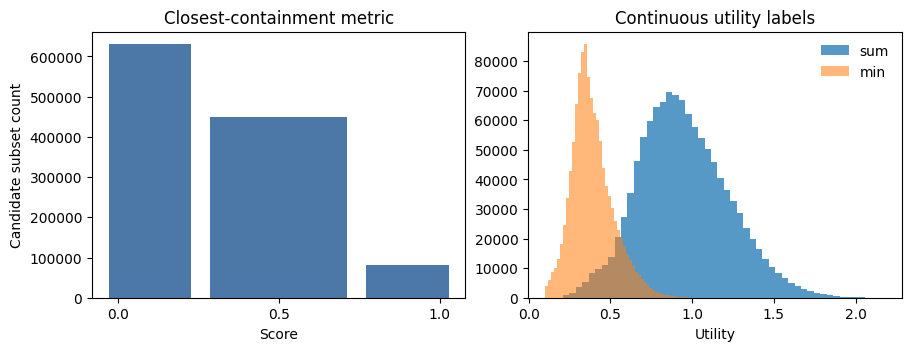

In [8]:
# Salvage/save the expensive processed state from the previous cell without rebuilding action rows.
# Use this if the previous cell finished `build_processed_two_tower_data(...)` and vectorized labels,
# then failed while trimming to missing refined audio bands.
from pathlib import Path
import importlib
import sys

from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

if "PROJECT_ROOT" not in globals():
    PROJECT_ROOT = Path.cwd()
    if PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.append(str(SCRIPTS_DIR))

import multi_processed_feature_builder
importlib.reload(multi_processed_feature_builder)
from multi_processed_feature_builder import save_processed_two_tower_data

required = ["base", "examples_df", "sequence_df", "feature_wide_df", "vehicle_labels", "ordered_nodes"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        "Cannot salvage yet. Run the previous cell until after vectorized labels are computed. "
        f"Missing: {missing}"
    )

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SALVAGE_PREFIX = "m01_multi_vehicle_sensor_subset_200ms_rssi_static"

examples_save = examples_df.copy().reset_index(drop=True)
sequence_save = sequence_df.copy().sort_values("time_id").drop_duplicates("time_id").reset_index(drop=True)
feature_wide_save = feature_wide_df.copy()
if feature_wide_save.index.name != "datetime":
    feature_wide_save.index.name = "datetime"

base_context_names = list(base["meta"]["context_feature_names"])
base_action_names = list(base["meta"]["action_feature_names"])
subset_key = "subset_str" if "subset_str" in examples_save.columns else "subset"

# Accuracy metric requested for two vehicles: 1.0 if both closest sensors are present,
# 0.5 if exactly one is present, 0.0 if neither is present. This is a metric column,
# not the training utility target.
contains_cols = [f"contains_closest_node_{v}" for v in vehicle_labels]
missing_contains = [col for col in contains_cols if col not in examples_save.columns]
if missing_contains:
    raise RuntimeError(f"Per-vehicle containment labels are missing: {missing_contains}")
examples_save["contains_closest_count"] = examples_save[contains_cols].sum(axis=1).astype(np.int16)
examples_save["contains_closest_fraction"] = examples_save["contains_closest_count"] / float(len(vehicle_labels))
examples_save["contains_closest_any"] = (examples_save["contains_closest_count"] >= 1).astype(np.int8)
examples_save["contains_closest_all"] = (examples_save["contains_closest_count"] == len(vehicle_labels)).astype(np.int8)

# Keep the continuous utility for training. The containment fraction is saved for evaluation.
utility_cols = [f"utility_{v}" for v in vehicle_labels]
if "utility_sum" not in examples_save.columns:
    examples_save["utility_sum"] = examples_save[utility_cols].sum(axis=1)
if "utility_mean" not in examples_save.columns:
    examples_save["utility_mean"] = examples_save[utility_cols].mean(axis=1)
if "utility_min" not in examples_save.columns:
    examples_save["utility_min"] = examples_save[utility_cols].min(axis=1)
if "utility_balanced" not in examples_save.columns:
    examples_save["utility_balanced"] = 0.5 * examples_save["utility_mean"] + 0.5 * examples_save["utility_min"]
examples_save["utility"] = examples_save["utility_sum"]
examples_save["contains_closest_node"] = examples_save["contains_closest_all"].astype(np.int8)

# Use only what is actually available in the current kernel: normalized node coords + rssi_db.
# Refined v3 audio bands were not present in audio_feature_long for this run, which is why the
# previous cell failed. This artifact is therefore the RSSI/static-action salvage artifact.
context_feature_names = []
for node in ordered_nodes:
    context_feature_names.extend([f"n{node}_sensor_x_norm", f"n{node}_sensor_y_norm"])
for node in ordered_nodes:
    context_feature_names.append(f"n{node}_rssi_db")

missing_context = [name for name in context_feature_names if name not in base_context_names]
if missing_context:
    raise RuntimeError(f"Missing required salvage context features: {missing_context[:20]}")
context_keep_idx = [base_context_names.index(name) for name in context_feature_names]

sequence_save["context_vec"] = sequence_save["context_vec"].apply(
    lambda x: np.asarray(x, dtype=np.float32)[context_keep_idx]
)
examples_save["context_vec"] = examples_save["context_vec"].apply(
    lambda x: np.asarray(x, dtype=np.float32)[context_keep_idx]
)
feature_wide_cols = [name for name in context_feature_names if name in feature_wide_save.columns]
feature_wide_save = feature_wide_save[feature_wide_cols].copy()

# Rebuild static action vectors: masks + canonical slot coordinates + subset_size.
mask_names = [name for name in base_action_names if name.startswith("mask_n")]
static_action_names = []
static_action_names.extend(mask_names)
for slot in (1, 2, 3):
    static_action_names.extend([f"slot{slot}_sensor_x_norm", f"slot{slot}_sensor_y_norm"])
static_action_names.append("subset_size")

def parse_subset_nodes(label: str) -> list[int]:
    cleaned = str(label).replace("(", "").replace(")", "").replace(",", "-").replace(" ", "")
    return [int(part) for part in cleaned.split("-") if part]

sensor_xy = {}
for node in ordered_nodes:
    sensor_xy[int(node)] = (
        float(sequence_save.iloc[0]["context_vec"][context_feature_names.index(f"n{node}_sensor_x_norm")]),
        float(sequence_save.iloc[0]["context_vec"][context_feature_names.index(f"n{node}_sensor_y_norm")]),
    )

missing_action = [name for name in mask_names if name not in base_action_names]
if missing_action or "subset_size" not in examples_save.columns:
    raise RuntimeError(f"Missing action fields: masks={missing_action}, subset_size={'subset_size' not in examples_save.columns}")

def build_static_action_vec(row) -> np.ndarray:
    raw = np.asarray(row["action_raw_vec"], dtype=np.float32)
    values = [float(raw[base_action_names.index(name)]) for name in mask_names]
    nodes = parse_subset_nodes(str(row[subset_key]))
    for slot_idx in range(3):
        if slot_idx < len(nodes):
            values.extend(sensor_xy[int(nodes[slot_idx])])
        else:
            values.extend([0.0, 0.0])
    values.append(float(row["subset_size"]))
    return np.asarray(values, dtype=np.float32)

examples_save["action_raw_vec"] = examples_save.apply(build_static_action_vec, axis=1)

static_action_matrix = np.stack(examples_save["action_raw_vec"].to_numpy()).astype(np.float32)
static_check = pd.DataFrame(static_action_matrix, columns=static_action_names)
static_check["subset_key"] = examples_save[subset_key].astype(str).to_numpy()
static_drift = float(
    (static_check.groupby("subset_key")[static_action_names].max() -
     static_check.groupby("subset_key")[static_action_names].min()).to_numpy().max()
)
assert static_drift <= 1e-6, f"Static action features drift across time: {static_drift:.3g}"

if "ground_truth_vehicle_rows" in globals():
    ground_truth_vehicle_df = pd.DataFrame(ground_truth_vehicle_rows)
elif "ground_truth_vehicle_df" not in globals():
    ground_truth_vehicle_df = base["ground_truth_vehicle_df"].copy()

if "ground_truth_node_rows" in globals():
    ground_truth_node_df = pd.DataFrame(ground_truth_node_rows)
elif "ground_truth_node_df" not in globals():
    ground_truth_node_df = base["ground_truth_node_df"].copy()

meta = dict(base["meta"])
meta.update(
    {
        "multi_vehicle": True,
        "vehicle_labels": list(vehicle_labels),
        "num_vehicles": int(len(vehicle_labels)),
        "num_times": int(len(sequence_save)),
        "num_examples": int(len(examples_save)),
        "context_dim": int(len(context_feature_names)),
        "action_raw_dim": int(len(static_action_names)),
        "context_feature_names": list(context_feature_names),
        "action_feature_names": list(static_action_names),
        "static_action_feature_names": list(static_action_names),
        "rssi_ablation_context_feature_names": [f"n{node}_rssi_db" for node in ordered_nodes],
        "default_utility_column": "utility_sum",
        "available_multi_vehicle_utility_columns": ["utility_sum", "utility_mean", "utility_min", "utility_balanced"],
        "multi_vehicle_metric_columns": [
            "contains_closest_fraction",
            "contains_closest_count",
            "contains_closest_any",
            "contains_closest_all",
        ],
        "contains_closest_fraction_definition": "1.0 if all vehicles' closest sensors are in the subset, 0.5 for one of two, 0.0 for none.",
        "contains_closest_node_definition": "Backward-compatible binary label: 1 iff all vehicles' closest sensors are in the subset.",
        "salvage_note": "Saved from the live kernel after the expensive shared action-row construction. Refined v3 audio bands were unavailable; this artifact keeps normalized node coordinates, rssi_db, static actions, and multi-vehicle labels/metrics.",
    }
)

processed_salvage = {
    "feature_wide_df": feature_wide_save,
    "node_feature_df": base["node_feature_df"].copy(),
    "ground_truth_node_df": ground_truth_node_df,
    "ground_truth_vehicle_df": ground_truth_vehicle_df,
    "sensor_geometry_df": base["sensor_geometry_df"].copy(),
    "sequence_df": sequence_save,
    "examples_df": examples_save,
    "meta": meta,
}

saved_paths = save_processed_two_tower_data(processed_salvage, processed_dir=PROCESSED_DIR, prefix=SALVAGE_PREFIX)
arrays = np.load(saved_paths["arrays_npz"], allow_pickle=True)
examples_index = pd.read_csv(saved_paths["examples_index_csv"])

per_time_counts = examples_index.groupby("time_id").size()
assert per_time_counts.nunique() == 1, per_time_counts.describe()
assert arrays["C_by_time"].shape[1] == len(context_feature_names)
assert arrays["A_examples"].shape[1] == len(static_action_names)
assert arrays["y_examples"].shape[0] == len(examples_index)
for col in ["contains_closest_fraction", "contains_closest_count", "contains_closest_any", "contains_closest_all"]:
    assert col in examples_index.columns, col

summary = pd.DataFrame([
    {
        "prefix": SALVAGE_PREFIX,
        "times": len(sequence_save),
        "actions_per_time": int(per_time_counts.iloc[0]),
        "examples": len(examples_index),
        "context_dim": arrays["C_by_time"].shape[1],
        "action_dim": arrays["A_examples"].shape[1],
        "static_action_drift": static_drift,
        "mean_contains_fraction": float(examples_index["contains_closest_fraction"].mean()),
        "contains_any_rate": float(examples_index["contains_closest_any"].mean()),
        "contains_all_rate": float(examples_index["contains_closest_all"].mean()),
        "utility_sum_mean": float(examples_index["utility_sum"].mean()),
    }
])
print("Salvaged and saved processed multi-vehicle artifact")
display(summary)
display(pd.DataFrame([{"artifact": key, "path": str(path)} for key, path in saved_paths.items()]))

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), constrained_layout=True)
axes[0].hist(examples_index["contains_closest_fraction"], bins=[-0.05, 0.25, 0.75, 1.05], color="#4c78a8", rwidth=0.85)
axes[0].set_xticks([0.0, 0.5, 1.0])
axes[0].set_title("Closest-containment metric")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Candidate subset count")
axes[1].hist(examples_index["utility_sum"], bins=50, alpha=0.75, label="sum")
axes[1].hist(examples_index["utility_min"], bins=50, alpha=0.55, label="min")
axes[1].set_title("Continuous utility labels")
axes[1].set_xlabel("Utility")
axes[1].legend(frameon=False)
plt.show()


In [ ]:
# Build a separate <=5 multi-vehicle processed set without touching the <=3 fallback artifact.
# This slim artifact keeps the feature scope intentionally small for utility-function experiments:
# context = normalized node coordinates + RSSI dB, action = subset mask + canonical slot coordinates + subset size.

import json
import time
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

REQUIRED = ["PROJECT_ROOT", "gdf_cleaned", "gdf_nodes", "valid_indices", "node_list"]
missing = [name for name in REQUIRED if name not in globals()]
if missing:
    raise RuntimeError(f"Run the loader/smoke-test cells first. Missing: {missing}")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
LEQ5_PREFIX = "m01_multi_vehicle_sensor_subset_200ms_rssi_static_leq5"
MAX_SUBSET_SIZE = 5
HISTORY_STEPS = 5
UTILITY_SECOND_WEIGHT = 0.45
UTILITY_THIRD_WEIGHT = 0.20
RHO = None

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
started = time.time()

ordered_nodes = sorted(int(n) for n in node_list)
N = len(ordered_nodes)
vehicle_labels = sorted(
    [col.replace("geometry_", "") for col in gdf_cleaned.columns if col.startswith("geometry_vehicle")],
    key=lambda x: int(x.replace("vehicle", "")),
)
if len(vehicle_labels) < 2:
    raise RuntimeError(f"Expected multiple vehicles, found {vehicle_labels}")

seq = gdf_cleaned.iloc[valid_indices].copy().sort_index()
datetimes = pd.DatetimeIndex(seq.index)
T = len(seq)
print(f"Building <=5 artifact: {T} timestamps, {N} nodes, vehicles={vehicle_labels}")

# Sensor geometry: use the projected local coordinates already produced by multi_dataloader.
nodes = gdf_nodes.copy()
node_id_col = "Node #" if "Node #" in nodes.columns else "Node"
nodes[node_id_col] = nodes[node_id_col].astype(int)
nodes = nodes[nodes[node_id_col].isin(ordered_nodes)].copy().set_index(node_id_col).loc[ordered_nodes]
x_m = nodes.geometry.x.to_numpy(dtype=float)
y_m = nodes.geometry.y.to_numpy(dtype=float)
x_norm = (x_m - x_m.min()) / max(x_m.max() - x_m.min(), 1e-12)
y_norm = (y_m - y_m.min()) / max(y_m.max() - y_m.min(), 1e-12)
node_to_idx = {node: i for i, node in enumerate(ordered_nodes)}
node_xy = {node: (float(x_norm[i]), float(y_norm[i])) for i, node in enumerate(ordered_nodes)}

# RSSI matrix in dB. Fill occasional missing entries with the node median.
rssi_cols = [f"rpi{node}" for node in ordered_nodes]
missing_rssi = [col for col in rssi_cols if col not in seq.columns]
if missing_rssi:
    raise RuntimeError(f"Missing RSSI columns: {missing_rssi}")
rssi_df = seq[rssi_cols].astype(float)
rssi_df = rssi_df.fillna(rssi_df.median()).fillna(rssi_df.stack().median()).fillna(0.0)
rssi = rssi_df.to_numpy(dtype=np.float32)

# Context vectors: coords first, then RSSI. No vehicle location leakage.
context_feature_names = []
context_parts = []
for i, node in enumerate(ordered_nodes):
    context_feature_names.extend([f"n{node}_sensor_x_norm", f"n{node}_sensor_y_norm"])
    context_parts.append(np.full((T, 1), x_norm[i], dtype=np.float32))
    context_parts.append(np.full((T, 1), y_norm[i], dtype=np.float32))
for i, node in enumerate(ordered_nodes):
    context_feature_names.append(f"n{node}_rssi_db")
    context_parts.append(rssi[:, i : i + 1].astype(np.float32))
C_by_time = np.hstack(context_parts).astype(np.float32)
sequence_df = pd.DataFrame({
    "time_id": np.arange(T, dtype=np.int32),
    "datetime": datetimes,
    "context_vec": list(C_by_time),
    "num_actions": 0,
})

feature_wide_df = pd.DataFrame(C_by_time, index=datetimes, columns=context_feature_names)
feature_wide_df.index.name = "datetime"

node_feature_rows = []
for j, node in enumerate(ordered_nodes):
    node_feature_rows.append(pd.DataFrame({
        "datetime": datetimes,
        "node": node,
        "sensor_x_norm": float(x_norm[j]),
        "sensor_y_norm": float(y_norm[j]),
        "rssi_db": rssi[:, j],
    }))
node_feature_df = pd.concat(node_feature_rows, ignore_index=True)

# Per-vehicle distance/rank tensors: shape (vehicles, time, node)
V = len(vehicle_labels)
dist = np.empty((V, T, N), dtype=np.float32)
for v, vehicle in enumerate(vehicle_labels, start=1):
    for j, node in enumerate(ordered_nodes):
        col = f"distance_to_{node}_vehicle{v}"
        if col not in seq.columns:
            raise RuntimeError(f"Missing distance column: {col}")
        dist[v - 1, :, j] = seq[col].to_numpy(dtype=np.float32)

closest_idx = np.argmin(dist, axis=2).astype(np.int16)
closest_node = np.take(np.asarray(ordered_nodes, dtype=np.int16), closest_idx)
rank = np.empty_like(closest_idx[..., None].repeat(N, axis=2), dtype=np.int16)
for v in range(V):
    order = np.argsort(dist[v], axis=1)
    rank[v] = np.empty((T, N), dtype=np.int16)
    row_idx = np.arange(T)[:, None]
    rank[v][row_idx, order] = np.arange(1, N + 1, dtype=np.int16)[None, :]

all_d1 = dist.min(axis=2).reshape(-1)
rho = float(np.median(all_d1[np.isfinite(all_d1)])) if RHO is None else float(RHO)
rho = max(rho, 1e-6)
print(f"rho={rho:.3f} m")

# Static action catalog for all subsets of size <=5.
subsets = []
for k in range(1, min(MAX_SUBSET_SIZE, N) + 1):
    subsets.extend(tuple(c) for c in combinations(ordered_nodes, k))
M = len(subsets)
sequence_df["num_actions"] = M
print(f"candidate subsets per timestamp: {M} (<= {MAX_SUBSET_SIZE})")

slot_count = MAX_SUBSET_SIZE
action_feature_names = [f"mask_n{node}" for node in ordered_nodes]
for slot in range(1, slot_count + 1):
    action_feature_names.extend([f"slot{slot}_sensor_x_norm", f"slot{slot}_sensor_y_norm"])
action_feature_names.append("subset_size")

A_catalog = np.zeros((M, len(action_feature_names)), dtype=np.float32)
subset_strs = []
subset_sizes = np.zeros(M, dtype=np.int16)
subset_node_idxs = []
for m, subset in enumerate(subsets):
    idxs = np.asarray([node_to_idx[n] for n in subset], dtype=np.int16)
    subset_node_idxs.append(idxs)
    subset_strs.append("-".join(str(n) for n in subset))
    subset_sizes[m] = len(subset)
    A_catalog[m, idxs] = 1.0
    cursor = N
    for slot_idx in range(slot_count):
        if slot_idx < len(subset):
            node = subset[slot_idx]
            A_catalog[m, cursor] = node_xy[node][0]
            A_catalog[m, cursor + 1] = node_xy[node][1]
        cursor += 2
    A_catalog[m, -1] = len(subset)

# Vectorized utilities/metrics for every timestamp/action.
y = np.empty((T, M), dtype=np.float32)
utility_by_vehicle = np.empty((V, T, M), dtype=np.float32)
d1_by_vehicle = np.empty((V, T, M), dtype=np.float32)
d2_by_vehicle = np.full((V, T, M), np.nan, dtype=np.float32)
d3_by_vehicle = np.full((V, T, M), np.nan, dtype=np.float32)
contains_by_vehicle = np.zeros((V, T, M), dtype=np.int8)
best_rank_by_vehicle = np.empty((V, T, M), dtype=np.int16)

for m, idxs in enumerate(subset_node_idxs):
    for v in range(V):
        d_sorted = np.sort(dist[v][:, idxs], axis=1)
        d1 = d_sorted[:, 0]
        d2 = d_sorted[:, 1] if len(idxs) >= 2 else np.full(T, np.nan, dtype=np.float32)
        d3 = d_sorted[:, 2] if len(idxs) >= 3 else np.full(T, np.nan, dtype=np.float32)
        term1 = 1.0 / (1.0 + d1 / rho)
        term2 = np.where(np.isfinite(d2), UTILITY_SECOND_WEIGHT / (1.0 + d2 / rho), 0.0)
        term3 = np.where(np.isfinite(d3), UTILITY_THIRD_WEIGHT / (1.0 + d3 / rho), 0.0)
        utility_by_vehicle[v, :, m] = (term1 + term2 + term3).astype(np.float32)
        d1_by_vehicle[v, :, m] = d1.astype(np.float32)
        d2_by_vehicle[v, :, m] = d2.astype(np.float32)
        d3_by_vehicle[v, :, m] = d3.astype(np.float32)
        contains_by_vehicle[v, :, m] = np.isin(closest_idx[v], idxs).astype(np.int8)
        best_rank_by_vehicle[v, :, m] = np.min(rank[v][:, idxs], axis=1).astype(np.int16)

y = utility_by_vehicle.sum(axis=0).astype(np.float32)
utility_mean = utility_by_vehicle.mean(axis=0).astype(np.float32)
utility_min = utility_by_vehicle.min(axis=0).astype(np.float32)
utility_balanced = (0.5 * utility_mean + 0.5 * utility_min).astype(np.float32)
contains_count = contains_by_vehicle.sum(axis=0).astype(np.int8)
contains_fraction = (contains_count / float(V)).astype(np.float32)
contains_all = (contains_count == V).astype(np.int8)
contains_any = (contains_count > 0).astype(np.int8)
worst_rank = best_rank_by_vehicle.max(axis=0).astype(np.int16)
mean_rank = best_rank_by_vehicle.mean(axis=0).astype(np.float32)

# Long-form examples index. Keep vectors in arrays_npz, not as a huge object-column pickle.
time_id = np.repeat(np.arange(T, dtype=np.int32), M)
action_id = np.tile(np.arange(M, dtype=np.int32), T)
examples_index = pd.DataFrame({
    "time_id": time_id,
    "datetime": np.repeat(datetimes.to_numpy(dtype="datetime64[ns]"), M),
    "action_id": action_id,
    "subset_str": np.tile(np.asarray(subset_strs, dtype=object), T),
    "subset_size": np.tile(subset_sizes, T),
    "utility": y.reshape(-1),
    "utility_sum": y.reshape(-1),
    "utility_mean": utility_mean.reshape(-1),
    "utility_min": utility_min.reshape(-1),
    "utility_balanced": utility_balanced.reshape(-1),
    "contains_closest_count": contains_count.reshape(-1),
    "contains_closest_fraction": contains_fraction.reshape(-1),
    "contains_closest_any": contains_any.reshape(-1),
    "contains_closest_all": contains_all.reshape(-1),
    "contains_closest_node": contains_all.reshape(-1),
    "worst_vehicle_rank_in_subset": worst_rank.reshape(-1),
    "mean_vehicle_rank_in_subset": mean_rank.reshape(-1),
    "d1": d1_by_vehicle.max(axis=0).reshape(-1),
    "best_rank_in_subset": worst_rank.reshape(-1),
})
for v, vehicle in enumerate(vehicle_labels):
    examples_index[f"utility_{vehicle}"] = utility_by_vehicle[v].reshape(-1)
    examples_index[f"d1_{vehicle}"] = d1_by_vehicle[v].reshape(-1)
    examples_index[f"d2_{vehicle}"] = d2_by_vehicle[v].reshape(-1)
    examples_index[f"d3_{vehicle}"] = d3_by_vehicle[v].reshape(-1)
    examples_index[f"contains_closest_node_{vehicle}"] = contains_by_vehicle[v].reshape(-1)
    examples_index[f"best_rank_in_subset_{vehicle}"] = best_rank_by_vehicle[v].reshape(-1)
    examples_index[f"closest_node_{vehicle}"] = np.repeat(closest_node[v], M)

# Ground-truth tables.
ground_truth_vehicle_rows = []
ground_truth_node_rows = []
for v, vehicle in enumerate(vehicle_labels):
    geom_col = f"geometry_{vehicle}"
    for t, dt in enumerate(datetimes):
        geom = seq.iloc[t][geom_col]
        ground_truth_vehicle_rows.append({
            "datetime": dt,
            "vehicle": vehicle,
            "vehicle_x_m": float(geom.x),
            "vehicle_y_m": float(geom.y),
            "closest_node": int(closest_node[v, t]),
            "nearest_distance_m": float(dist[v, t, closest_idx[v, t]]),
        })
    vehicle_node_rows = pd.DataFrame({
        "datetime": np.repeat(datetimes.to_numpy(dtype="datetime64[ns]"), N),
        "vehicle": vehicle,
        "node": np.tile(np.asarray(ordered_nodes, dtype=np.int16), T),
        "distance_to_vehicle_m": dist[v].reshape(-1),
        "distance_rank": rank[v].reshape(-1),
    })
    ground_truth_node_rows.append(vehicle_node_rows)

ground_truth_vehicle_df = pd.DataFrame(ground_truth_vehicle_rows)
ground_truth_node_df = pd.concat(ground_truth_node_rows, ignore_index=True)
sensor_geometry_df = pd.DataFrame({
    "node": ordered_nodes,
    "sensor_x_m": x_m,
    "sensor_y_m": y_m,
    "sensor_x_norm": x_norm,
    "sensor_y_norm": y_norm,
})

# Save a slim processed artifact. It intentionally skips examples.pkl because storing 4.2M rows
# with repeated ndarray object columns is slow and wasteful; arrays_npz + examples_index_csv are enough for training.
paths = {
    "feature_wide_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_feature_wide.csv",
    "node_features_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_node_features.csv",
    "ground_truth_nodes_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_ground_truth_nodes.csv",
    "ground_truth_vehicle_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_ground_truth_vehicle.csv",
    "sensor_geometry_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_sensor_geometry.csv",
    "sequence_pkl": PROCESSED_DIR / f"{LEQ5_PREFIX}_sequence.pkl",
    "examples_index_csv": PROCESSED_DIR / f"{LEQ5_PREFIX}_examples_index.csv",
    "arrays_npz": PROCESSED_DIR / f"{LEQ5_PREFIX}_arrays.npz",
    "meta_json": PROCESSED_DIR / f"{LEQ5_PREFIX}_meta.json",
}
feature_wide_df.reset_index().to_csv(paths["feature_wide_csv"], index=False)
node_feature_df.to_csv(paths["node_features_csv"], index=False)
ground_truth_node_df.to_csv(paths["ground_truth_nodes_csv"], index=False)
ground_truth_vehicle_df.to_csv(paths["ground_truth_vehicle_csv"], index=False)
sensor_geometry_df.to_csv(paths["sensor_geometry_csv"], index=False)
sequence_df.to_pickle(paths["sequence_pkl"])
examples_index.to_csv(paths["examples_index_csv"], index=False)

A_examples = A_catalog[action_id].astype(np.float32)
np.savez_compressed(
    paths["arrays_npz"],
    C_by_time=C_by_time,
    A_examples=A_examples,
    A_catalog=A_catalog,
    action_id=action_id,
    subset_key=np.asarray(subset_strs, dtype=object),
    y_examples=examples_index["utility"].to_numpy(dtype=np.float32),
    example_time_id=time_id,
    example_subset_size=examples_index["subset_size"].to_numpy(dtype=np.int16),
    example_d1=examples_index["d1"].to_numpy(dtype=np.float32),
    example_contains_closest=examples_index["contains_closest_node"].to_numpy(dtype=np.int8),
    example_contains_closest_fraction=examples_index["contains_closest_fraction"].to_numpy(dtype=np.float32),
    sequence_times=datetimes.to_numpy(dtype="datetime64[ns]"),
)

meta = {
    "ordered_nodes": ordered_nodes,
    "vehicle_labels": vehicle_labels,
    "multi_vehicle": True,
    "num_vehicles": V,
    "max_subset_size": MAX_SUBSET_SIZE,
    "subset_size_policy": "all subsets with size <= max_subset_size",
    "history_steps": HISTORY_STEPS,
    "utility_second_weight": UTILITY_SECOND_WEIGHT,
    "utility_third_weight": UTILITY_THIRD_WEIGHT,
    "rho": rho,
    "context_dim": int(C_by_time.shape[1]),
    "action_raw_dim": int(A_catalog.shape[1]),
    "num_times": int(T),
    "num_actions_per_time": int(M),
    "num_examples": int(len(examples_index)),
    "context_feature_names": context_feature_names,
    "action_feature_names": action_feature_names,
    "static_action_feature_names": action_feature_names,
    "default_utility_column": "utility_sum",
    "available_multi_vehicle_utility_columns": ["utility_sum", "utility_mean", "utility_min", "utility_balanced"],
    "multi_vehicle_metric_columns": [
        "contains_closest_fraction",
        "contains_closest_count",
        "contains_closest_any",
        "contains_closest_all",
    ],
    "contains_closest_fraction_definition": "1.0 if both vehicles' closest sensors are in the subset, 0.5 if exactly one is in the subset, 0.0 if none are in the subset.",
    "contains_closest_node_definition": "Backward-compatible binary label: 1 iff all vehicles' closest sensors are in the subset.",
    "leakage_note": "Context and action features exclude vehicle coordinates and vehicle-to-node distances. Targets and diagnostics are stored only in examples_index and ground-truth tables.",
    "slim_artifact": True,
    "skipped_examples_pkl_reason": "Avoids a very large object-column pickle for 4M+ examples; use arrays_npz plus examples_index_csv for training.",
    "fallback_leq3_prefix": "m01_multi_vehicle_sensor_subset_200ms_rssi_static",
}
with open(paths["meta_json"], "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"Saved <=5 artifact prefix: {LEQ5_PREFIX}")
print(f"actions/time={M}, examples={len(examples_index):,}, context_dim={C_by_time.shape[1]}, action_dim={A_catalog.shape[1]}")
print(f"mean contains fraction over all actions={examples_index['contains_closest_fraction'].mean():.4f}")
print(f"elapsed={(time.time() - started)/60:.1f} min")
for key, value in paths.items():
    print(f"{key}: {value}")


In [10]:
# Build a separate ==5 multi-vehicle processed set.
# This is the clean action space when the deployment budget is exactly five sensors.
# It leaves both existing fallback artifacts untouched:
#   - m01_multi_vehicle_sensor_subset_200ms_rssi_static       (<=3)
#   - m01_multi_vehicle_sensor_subset_200ms_rssi_static_leq5  (<=5, if you run that cell)

import json
import time
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd

REQUIRED = ["PROJECT_ROOT", "gdf_cleaned", "gdf_nodes", "valid_indices", "node_list"]
missing = [name for name in REQUIRED if name not in globals()]
if missing:
    raise RuntimeError(f"Run the loader/smoke-test cells first. Missing: {missing}")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
EQ5_PREFIX = "m01_multi_vehicle_sensor_subset_200ms_rssi_static_eq5"
EXACT_SUBSET_SIZE = 5
HISTORY_STEPS = 5
UTILITY_SECOND_WEIGHT = 0.45
UTILITY_THIRD_WEIGHT = 0.20
RHO = None

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
started = time.time()

ordered_nodes = sorted(int(n) for n in node_list)
N = len(ordered_nodes)
if EXACT_SUBSET_SIZE > N:
    raise RuntimeError(f"EXACT_SUBSET_SIZE={EXACT_SUBSET_SIZE} exceeds number of nodes N={N}")

vehicle_labels = sorted(
    [col.replace("geometry_", "") for col in gdf_cleaned.columns if col.startswith("geometry_vehicle")],
    key=lambda x: int(x.replace("vehicle", "")),
)
if len(vehicle_labels) < 2:
    raise RuntimeError(f"Expected multiple vehicles, found {vehicle_labels}")

seq = gdf_cleaned.iloc[valid_indices].copy().sort_index()
datetimes = pd.DatetimeIndex(seq.index)
T = len(seq)
print(f"Building ==5 artifact: {T} timestamps, {N} nodes, vehicles={vehicle_labels}")

nodes = gdf_nodes.copy()
node_id_col = "Node #" if "Node #" in nodes.columns else "Node"
nodes[node_id_col] = nodes[node_id_col].astype(int)
nodes = nodes[nodes[node_id_col].isin(ordered_nodes)].copy().set_index(node_id_col).loc[ordered_nodes]
x_m = nodes.geometry.x.to_numpy(dtype=float)
y_m = nodes.geometry.y.to_numpy(dtype=float)
x_norm = (x_m - x_m.min()) / max(x_m.max() - x_m.min(), 1e-12)
y_norm = (y_m - y_m.min()) / max(y_m.max() - y_m.min(), 1e-12)
node_to_idx = {node: i for i, node in enumerate(ordered_nodes)}
node_xy = {node: (float(x_norm[i]), float(y_norm[i])) for i, node in enumerate(ordered_nodes)}

rssi_cols = [f"rpi{node}" for node in ordered_nodes]
missing_rssi = [col for col in rssi_cols if col not in seq.columns]
if missing_rssi:
    raise RuntimeError(f"Missing RSSI columns: {missing_rssi}")
rssi_df = seq[rssi_cols].astype(float)
rssi_df = rssi_df.fillna(rssi_df.median()).fillna(rssi_df.stack().median()).fillna(0.0)
rssi = rssi_df.to_numpy(dtype=np.float32)

context_feature_names = []
context_parts = []
for i, node in enumerate(ordered_nodes):
    context_feature_names.extend([f"n{node}_sensor_x_norm", f"n{node}_sensor_y_norm"])
    context_parts.append(np.full((T, 1), x_norm[i], dtype=np.float32))
    context_parts.append(np.full((T, 1), y_norm[i], dtype=np.float32))
for i, node in enumerate(ordered_nodes):
    context_feature_names.append(f"n{node}_rssi_db")
    context_parts.append(rssi[:, i : i + 1].astype(np.float32))
C_by_time = np.hstack(context_parts).astype(np.float32)
sequence_df = pd.DataFrame({
    "time_id": np.arange(T, dtype=np.int32),
    "datetime": datetimes,
    "context_vec": list(C_by_time),
    "num_actions": 0,
})

feature_wide_df = pd.DataFrame(C_by_time, index=datetimes, columns=context_feature_names)
feature_wide_df.index.name = "datetime"

node_feature_df = pd.concat(
    [
        pd.DataFrame({
            "datetime": datetimes,
            "node": node,
            "sensor_x_norm": float(x_norm[j]),
            "sensor_y_norm": float(y_norm[j]),
            "rssi_db": rssi[:, j],
        })
        for j, node in enumerate(ordered_nodes)
    ],
    ignore_index=True,
)

V = len(vehicle_labels)
dist = np.empty((V, T, N), dtype=np.float32)
for v, vehicle in enumerate(vehicle_labels, start=1):
    for j, node in enumerate(ordered_nodes):
        col = f"distance_to_{node}_vehicle{v}"
        if col not in seq.columns:
            raise RuntimeError(f"Missing distance column: {col}")
        dist[v - 1, :, j] = seq[col].to_numpy(dtype=np.float32)

closest_idx = np.argmin(dist, axis=2).astype(np.int16)
closest_node = np.take(np.asarray(ordered_nodes, dtype=np.int16), closest_idx)
rank = np.empty((V, T, N), dtype=np.int16)
for v in range(V):
    order = np.argsort(dist[v], axis=1)
    row_idx = np.arange(T)[:, None]
    rank[v][row_idx, order] = np.arange(1, N + 1, dtype=np.int16)[None, :]

all_d1 = dist.min(axis=2).reshape(-1)
rho = float(np.median(all_d1[np.isfinite(all_d1)])) if RHO is None else float(RHO)
rho = max(rho, 1e-6)
print(f"rho={rho:.3f} m")

subsets = [tuple(c) for c in combinations(ordered_nodes, EXACT_SUBSET_SIZE)]
M = len(subsets)
sequence_df["num_actions"] = M
print(f"candidate subsets per timestamp: {M} (== {EXACT_SUBSET_SIZE})")

slot_count = EXACT_SUBSET_SIZE
action_feature_names = [f"mask_n{node}" for node in ordered_nodes]
for slot in range(1, slot_count + 1):
    action_feature_names.extend([f"slot{slot}_sensor_x_norm", f"slot{slot}_sensor_y_norm"])
action_feature_names.append("subset_size")

A_catalog = np.zeros((M, len(action_feature_names)), dtype=np.float32)
subset_strs = []
subset_sizes = np.full(M, EXACT_SUBSET_SIZE, dtype=np.int16)
subset_node_idxs = []
for m, subset in enumerate(subsets):
    idxs = np.asarray([node_to_idx[n] for n in subset], dtype=np.int16)
    subset_node_idxs.append(idxs)
    subset_strs.append("-".join(str(n) for n in subset))
    A_catalog[m, idxs] = 1.0
    cursor = N
    for slot_idx, node in enumerate(subset):
        A_catalog[m, cursor + 2 * slot_idx] = node_xy[node][0]
        A_catalog[m, cursor + 2 * slot_idx + 1] = node_xy[node][1]
    A_catalog[m, -1] = EXACT_SUBSET_SIZE

y = np.empty((T, M), dtype=np.float32)
utility_by_vehicle = np.empty((V, T, M), dtype=np.float32)
d1_by_vehicle = np.empty((V, T, M), dtype=np.float32)
d2_by_vehicle = np.empty((V, T, M), dtype=np.float32)
d3_by_vehicle = np.empty((V, T, M), dtype=np.float32)
contains_by_vehicle = np.zeros((V, T, M), dtype=np.int8)
best_rank_by_vehicle = np.empty((V, T, M), dtype=np.int16)

for m, idxs in enumerate(subset_node_idxs):
    for v in range(V):
        d_sorted = np.sort(dist[v][:, idxs], axis=1)
        d1 = d_sorted[:, 0]
        d2 = d_sorted[:, 1]
        d3 = d_sorted[:, 2]
        term1 = 1.0 / (1.0 + d1 / rho)
        term2 = UTILITY_SECOND_WEIGHT / (1.0 + d2 / rho)
        term3 = UTILITY_THIRD_WEIGHT / (1.0 + d3 / rho)
        utility_by_vehicle[v, :, m] = (term1 + term2 + term3).astype(np.float32)
        d1_by_vehicle[v, :, m] = d1.astype(np.float32)
        d2_by_vehicle[v, :, m] = d2.astype(np.float32)
        d3_by_vehicle[v, :, m] = d3.astype(np.float32)
        contains_by_vehicle[v, :, m] = np.isin(closest_idx[v], idxs).astype(np.int8)
        best_rank_by_vehicle[v, :, m] = np.min(rank[v][:, idxs], axis=1).astype(np.int16)

y = utility_by_vehicle.sum(axis=0).astype(np.float32)
utility_mean = utility_by_vehicle.mean(axis=0).astype(np.float32)
utility_min = utility_by_vehicle.min(axis=0).astype(np.float32)
utility_balanced = (0.5 * utility_mean + 0.5 * utility_min).astype(np.float32)
contains_count = contains_by_vehicle.sum(axis=0).astype(np.int8)
contains_fraction = (contains_count / float(V)).astype(np.float32)
contains_all = (contains_count == V).astype(np.int8)
contains_any = (contains_count > 0).astype(np.int8)
worst_rank = best_rank_by_vehicle.max(axis=0).astype(np.int16)
mean_rank = best_rank_by_vehicle.mean(axis=0).astype(np.float32)

time_id = np.repeat(np.arange(T, dtype=np.int32), M)
action_id = np.tile(np.arange(M, dtype=np.int32), T)
examples_index = pd.DataFrame({
    "time_id": time_id,
    "datetime": np.repeat(datetimes.to_numpy(dtype="datetime64[ns]"), M),
    "action_id": action_id,
    "subset_str": np.tile(np.asarray(subset_strs, dtype=object), T),
    "subset_size": np.tile(subset_sizes, T),
    "utility": y.reshape(-1),
    "utility_sum": y.reshape(-1),
    "utility_mean": utility_mean.reshape(-1),
    "utility_min": utility_min.reshape(-1),
    "utility_balanced": utility_balanced.reshape(-1),
    "contains_closest_count": contains_count.reshape(-1),
    "contains_closest_fraction": contains_fraction.reshape(-1),
    "contains_closest_any": contains_any.reshape(-1),
    "contains_closest_all": contains_all.reshape(-1),
    "contains_closest_node": contains_all.reshape(-1),
    "worst_vehicle_rank_in_subset": worst_rank.reshape(-1),
    "mean_vehicle_rank_in_subset": mean_rank.reshape(-1),
    "d1": d1_by_vehicle.max(axis=0).reshape(-1),
    "best_rank_in_subset": worst_rank.reshape(-1),
})
for v, vehicle in enumerate(vehicle_labels):
    examples_index[f"utility_{vehicle}"] = utility_by_vehicle[v].reshape(-1)
    examples_index[f"d1_{vehicle}"] = d1_by_vehicle[v].reshape(-1)
    examples_index[f"d2_{vehicle}"] = d2_by_vehicle[v].reshape(-1)
    examples_index[f"d3_{vehicle}"] = d3_by_vehicle[v].reshape(-1)
    examples_index[f"contains_closest_node_{vehicle}"] = contains_by_vehicle[v].reshape(-1)
    examples_index[f"best_rank_in_subset_{vehicle}"] = best_rank_by_vehicle[v].reshape(-1)
    examples_index[f"closest_node_{vehicle}"] = np.repeat(closest_node[v], M)

ground_truth_vehicle_rows = []
ground_truth_node_rows = []
for v, vehicle in enumerate(vehicle_labels):
    geom_col = f"geometry_{vehicle}"
    for t, dt in enumerate(datetimes):
        geom = seq.iloc[t][geom_col]
        ground_truth_vehicle_rows.append({
            "datetime": dt,
            "vehicle": vehicle,
            "vehicle_x_m": float(geom.x),
            "vehicle_y_m": float(geom.y),
            "closest_node": int(closest_node[v, t]),
            "nearest_distance_m": float(dist[v, t, closest_idx[v, t]]),
        })
    ground_truth_node_rows.append(pd.DataFrame({
        "datetime": np.repeat(datetimes.to_numpy(dtype="datetime64[ns]"), N),
        "vehicle": vehicle,
        "node": np.tile(np.asarray(ordered_nodes, dtype=np.int16), T),
        "distance_to_vehicle_m": dist[v].reshape(-1),
        "distance_rank": rank[v].reshape(-1),
    }))

ground_truth_vehicle_df = pd.DataFrame(ground_truth_vehicle_rows)
ground_truth_node_df = pd.concat(ground_truth_node_rows, ignore_index=True)
sensor_geometry_df = pd.DataFrame({
    "node": ordered_nodes,
    "sensor_x_m": x_m,
    "sensor_y_m": y_m,
    "sensor_x_norm": x_norm,
    "sensor_y_norm": y_norm,
})

paths = {
    "feature_wide_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_feature_wide.csv",
    "node_features_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_node_features.csv",
    "ground_truth_nodes_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_ground_truth_nodes.csv",
    "ground_truth_vehicle_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_ground_truth_vehicle.csv",
    "sensor_geometry_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_sensor_geometry.csv",
    "sequence_pkl": PROCESSED_DIR / f"{EQ5_PREFIX}_sequence.pkl",
    "examples_index_csv": PROCESSED_DIR / f"{EQ5_PREFIX}_examples_index.csv",
    "arrays_npz": PROCESSED_DIR / f"{EQ5_PREFIX}_arrays.npz",
    "meta_json": PROCESSED_DIR / f"{EQ5_PREFIX}_meta.json",
}
feature_wide_df.reset_index().to_csv(paths["feature_wide_csv"], index=False)
node_feature_df.to_csv(paths["node_features_csv"], index=False)
ground_truth_node_df.to_csv(paths["ground_truth_nodes_csv"], index=False)
ground_truth_vehicle_df.to_csv(paths["ground_truth_vehicle_csv"], index=False)
sensor_geometry_df.to_csv(paths["sensor_geometry_csv"], index=False)
sequence_df.to_pickle(paths["sequence_pkl"])
examples_index.to_csv(paths["examples_index_csv"], index=False)

A_examples = A_catalog[action_id].astype(np.float32)
np.savez_compressed(
    paths["arrays_npz"],
    C_by_time=C_by_time,
    A_examples=A_examples,
    A_catalog=A_catalog,
    action_id=action_id,
    subset_key=np.asarray(subset_strs, dtype=object),
    y_examples=examples_index["utility"].to_numpy(dtype=np.float32),
    example_time_id=time_id,
    example_subset_size=examples_index["subset_size"].to_numpy(dtype=np.int16),
    example_d1=examples_index["d1"].to_numpy(dtype=np.float32),
    example_contains_closest=examples_index["contains_closest_node"].to_numpy(dtype=np.int8),
    example_contains_closest_fraction=examples_index["contains_closest_fraction"].to_numpy(dtype=np.float32),
    sequence_times=datetimes.to_numpy(dtype="datetime64[ns]"),
)

meta = {
    "ordered_nodes": ordered_nodes,
    "vehicle_labels": vehicle_labels,
    "multi_vehicle": True,
    "num_vehicles": V,
    "max_subset_size": EXACT_SUBSET_SIZE,
    "exact_subset_size": EXACT_SUBSET_SIZE,
    "subset_size_policy": "exactly max_subset_size",
    "history_steps": HISTORY_STEPS,
    "utility_second_weight": UTILITY_SECOND_WEIGHT,
    "utility_third_weight": UTILITY_THIRD_WEIGHT,
    "rho": rho,
    "context_dim": int(C_by_time.shape[1]),
    "action_raw_dim": int(A_catalog.shape[1]),
    "num_times": int(T),
    "num_actions_per_time": int(M),
    "num_examples": int(len(examples_index)),
    "context_feature_names": context_feature_names,
    "action_feature_names": action_feature_names,
    "static_action_feature_names": action_feature_names,
    "default_utility_column": "utility_sum",
    "available_multi_vehicle_utility_columns": ["utility_sum", "utility_mean", "utility_min", "utility_balanced"],
    "multi_vehicle_metric_columns": [
        "contains_closest_fraction",
        "contains_closest_count",
        "contains_closest_any",
        "contains_closest_all",
    ],
    "contains_closest_fraction_definition": "1.0 if both vehicles' closest sensors are in the subset, 0.5 if exactly one is in the subset, 0.0 if none are in the subset.",
    "contains_closest_node_definition": "Backward-compatible binary label: 1 iff all vehicles' closest sensors are in the subset.",
    "leakage_note": "Context and action features exclude vehicle coordinates and vehicle-to-node distances. Targets and diagnostics are stored only in examples_index and ground-truth tables.",
    "slim_artifact": True,
    "skipped_examples_pkl_reason": "Avoids a large object-column pickle; use arrays_npz plus examples_index_csv for training.",
    "fallback_leq3_prefix": "m01_multi_vehicle_sensor_subset_200ms_rssi_static",
    "optional_leq5_prefix": "m01_multi_vehicle_sensor_subset_200ms_rssi_static_leq5",
}
with open(paths["meta_json"], "w", encoding="utf-8") as f:
    json.dump(meta, f, indent=2)

print(f"Saved ==5 artifact prefix: {EQ5_PREFIX}")
print(f"actions/time={M}, examples={len(examples_index):,}, context_dim={C_by_time.shape[1]}, action_dim={A_catalog.shape[1]}")
print(f"mean contains fraction over all actions={examples_index['contains_closest_fraction'].mean():.4f}")
print(f"elapsed={(time.time() - started)/60:.1f} min")
for key, value in paths.items():
    print(f"{key}: {value}")


Building ==5 artifact: 6625 timestamps, 10 nodes, vehicles=['vehicle1', 'vehicle2']
rho=10.222 m
candidate subsets per timestamp: 252 (== 5)
Saved ==5 artifact prefix: m01_multi_vehicle_sensor_subset_200ms_rssi_static_eq5
actions/time=252, examples=1,669,500, context_dim=30, action_dim=21
mean contains fraction over all actions=0.5000
elapsed=0.7 min
feature_wide_csv: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\processed\m01_multi_vehicle_sensor_subset_200ms_rssi_static_eq5_feature_wide.csv
node_features_csv: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\processed\m01_multi_vehicle_sensor_subset_200ms_rssi_static_eq5_node_features.csv
ground_truth_nodes_csv: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\processed\m01_multi_vehicle_sensor_subset_200ms_rssi_static_eq5_ground_truth_nodes.csv
ground_truth_vehicle_csv: d:\2023-2028_UCLA_Research_Projects\IoBT\17-5-26-MILCOMAttempt\data\processed\m01_multi_vehicle_sensor_sub